In [1]:
from six.moves import cPickle as pickle  # for performance
def load_dict(filename_):
    with open(filename_, "rb") as f:
        ret_di = pickle.load(f)
    return ret_di

DATA_DIR="/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/mydiffuse/eval/new_tcd_timit_test.pkl"
files_list = load_dict(DATA_DIR)
len(files_list)

900

In [2]:
# Display results in rows
import pandas as pd
from IPython.display import display, HTML
import numpy as np

def display_df(params, snr_min = -5, snr_max = 5, metric_mode="mean"):
    
    metric_columns = ["SI-SDR", "SI-SIR", "SI-SAR", "PESQ", "STOI"] #["SI-SDR", "PESQ", "STOI", "MOS_SIG", "MOS_BAK", "MOS_OVR"]
    combined_results = pd.DataFrame(columns=["SI-SDR ± SE", "SI-SIR ± SE","SI-SAR ± SE","PESQ ± SE", "STOI ± SE"])

    for key, filepath in params.items():
        df = pd.read_csv(filepath)

        # Filter the DataFrame
        condition = (df["Noise SNR"] >= snr_min) & (
            df["Noise SNR"] <= snr_max
        ) # & (df['Noise Type'] != 'Cafe') #& (df['Noise Type'] != 'Street') & (df['Noise Type'] != 'Cafe') & (df['Noise Type'] != 'Car')
        df_filtered = df[condition]
        # print(len(df_filtered), df_filtered["Noise Type"].unique())
        # Calculate average and standard error
        if metric_mode == "mean":
            average = df_filtered[metric_columns].mean()
        elif metric_mode == "median":
            average = df_filtered[metric_columns].median()
        standard_error = df_filtered[metric_columns].std() / np.sqrt(len(df_filtered))

        # Round the values to two decimal places
        average = average.round(2)
        standard_error = standard_error.round(2)

        # Create a new DataFrame for the data frame's metrics and their standard errors
        df_row = pd.DataFrame(
            {
                f"{metric} ± SE": [f"{average[metric]} ± {standard_error[metric]}"]
                for metric in metric_columns
            }
        )
        df_row.index = [key]

        # Append the data frame's row to the combined results DataFrame
        combined_results = pd.concat([combined_results, df_row])
    

    # Display the combined results
    #display(combined_results)
    return combined_results

def display_df1(params, snr_min = -5, snr_max = 5, metric_mode="mean"):
    
    
    metric_columns = ["SI-SDR", "SI-SIR", "SI-SAR", "PESQ", "STOI"] #["SI-SDR", "PESQ", "STOI", "MOS_SIG", "MOS_BAK", "MOS_OVR"]
    combined_results = pd.DataFrame(columns=["fusion", "visual embedding", "SI-SDR ± SE", "SI-SIR ± SE","SI-SAR ± SE","PESQ ± SE", "STOI ± SE"])

    fusions = [e["fusion"] for e in params.values()]
    visual_embedings = [e["visual embedding"] for e in params.values()]
    #for key, filepath in params.items():
    keys = params.keys()
    filepaths = [e["filepath"] for e in params.values()]
    for key, filepath, fusion, visual_embeding in zip(keys, filepaths, fusions, visual_embedings):
        df = pd.read_csv(filepath)

        # Filter the DataFrame
        condition = (df["Noise SNR"] >= snr_min) & (
            df["Noise SNR"] <= snr_max
        ) # & (df['Noise Type'] != 'Cafe') #& (df['Noise Type'] != 'Street') & (df['Noise Type'] != 'Cafe') & (df['Noise Type'] != 'Car')
        df_filtered = df[condition]
        # print(len(df_filtered), df_filtered["Noise Type"].unique())
        # Calculate average and standard error
        if metric_mode == "mean":
            average = df_filtered[metric_columns].mean()
        elif metric_mode == "median":
            average = df_filtered[metric_columns].median()
        standard_error = df_filtered[metric_columns].std() / np.sqrt(len(df_filtered))

        # Round the values to two decimal places
        average = average.round(2)
        standard_error = standard_error.round(2)

        # Create a new DataFrame for the data frame's metrics and their standard errors
        df_row = pd.DataFrame(
            {
                f"{metric} ± SE": [f"{average[metric]} ± {standard_error[metric]}"]
                for metric in metric_columns
            }
        )
        df_row.index = [key]
        

        # Append the data frame's row to the combined results DataFrame
        combined_results = pd.concat([combined_results, df_row])
        combined_results.at[key, "fusion"] = fusion
        combined_results.at[key, "visual embedding"] = visual_embeding
        
    

    # Display the combined results
    #display(combined_results)
    return combined_results

In [3]:

# seminal
def mean_per_group(dict_, group = "snr" , colormax=0) :
    
    metrics = ["SI-SDR","PESQ","STOI"]

    if group == "snr":
        a_df = pd.read_csv( dict_[list(dict_.keys())[0]] ) 
        elements_group = list(a_df.groupby(["Noise SNR"]).mean().index)
        
        
    elif group == "ntype":
        a_df = pd.read_csv( dict_[list(dict_.keys())[0]] )  
        elements_group = list(a_df.groupby(["Noise Type"]).mean().index)


    dico = {}


    for (name,file) in dict_.items() :
        
        general_df = pd.read_csv(file)

        if group == "snr":
            df = round(general_df.groupby(["Noise SNR"]).mean(),2)
        
        elif group == "ntype":
            df = round(general_df.groupby(["Noise Type"]).mean(),2)        
        
        values = []
        
        #values.extend(df.si_sar.tolist())
        #values.extend(df.si_sir)
        #values.extend(df.estoi)

        values.extend(df["SI-SDR"])
        values.extend(df["PESQ"])
        values.extend(df["STOI"])    
            
        dico[name] = values


    df_per_group = pd.DataFrame.from_dict(dico, orient='index')#,index=nickname)

    ##cartesian product
    metric_levels = [item for item in metrics for i in range(len(elements_group))]
    group_levels = elements_group*len(metrics)
    tuples = list(zip(metric_levels,group_levels))

    if group == "snr":
        df_per_group.columns = pd.MultiIndex.from_tuples(tuples, names=["Metrics", "SNRs"])
        #df_per_group.index = list(dict_.keys())
    elif group == "ntype":
        df_per_group.columns = pd.MultiIndex.from_tuples(tuples, names=["Metrics", "Noise types"])
        #df_per_group.index = list(dict_.keys())


    # return df_per_group
    if colormax == 0:
        display(df_per_group)
 
    elif colormax == 1 :
        display(df_per_group.style.pipe(make_pretty_1))
    
    elif colormax == 2 :
        display(df_per_group.style.pipe(make_pretty_2))
# new handles SIR And SAR
def mean_per_group(dict_, group="snr", colormax=0):

    metrics = ["SI-SDR", "SI-SIR", "SI-SAR", "PESQ", "STOI"]

    # --- read first file to get group levels ---
    first_key = list(dict_.keys())[0]
    first_path = dict_[first_key]["filepath"]
    a_df = pd.read_csv(first_path)

    if group == "snr":
        elements_group = list(a_df.groupby("Noise SNR").mean().index)
        group_col = "Noise SNR"
        group_name = "SNRs"

    elif group == "ntype":
        elements_group = list(a_df.groupby("Noise Type").mean().index)
        group_col = "Noise Type"
        group_name = "Noise types"

    else:
        raise ValueError(f"Unknown group: {group}")

    dico = {}

    # --- main loop ---
    for name, cfg in dict_.items():
        filepath = cfg["filepath"]
        general_df = pd.read_csv(filepath)

        df = round(general_df.groupby(group_col).mean(), 2)

        values = []
        for m in metrics:
            values.extend(df[m].tolist())

        dico[name] = values

    # --- build dataframe ---
    df_per_group = pd.DataFrame.from_dict(dico, orient="index")

    # cartesian product for MultiIndex columns
    metric_levels = [m for m in metrics for _ in range(len(elements_group))]
    group_levels = elements_group * len(metrics)
    tuples = list(zip(metric_levels, group_levels))

    df_per_group.columns = pd.MultiIndex.from_tuples(
        tuples, names=["Metrics", group_name]
    )

    # --- display ---
    if colormax == 0:
        display(df_per_group)
    elif colormax == 1:
        display(df_per_group.style.pipe(make_pretty_1))
    elif colormax == 2:
        display(df_per_group.style.pipe(make_pretty_2))


def make_pretty_1(styler):
    styler.format(precision=2, thousands=".", decimal=",") 
    styler.highlight_max(color = 'color:white;background-color:darkblue', axis = 0)    
    #styler.apply(highlight_max, props1='color:white;background-color:darkblue', axis=0)    
    return styler

def make_pretty_2(styler):
    styler.format(precision=2, thousands=".", decimal=",") 
    # styler.highlight_max(color = 'color:white;background-color:darkblue', axis = 0)    
    styler.apply(highlight_max, props1='color:white;background-color:darkblue', axis=0)    
    styler.apply(highlight_secondmax, props2='color:white;background-color:lightblue', axis=0)
    return styler

def highlight_max(s, props1=''):
    if s.dtype ==object:
        s = s.apply(lambda x: x.split("±")[0])
        s = s.astype(float)    
    return np.where(s == list(s.nlargest(2))[0], props1,'') 

def highlight_secondmax(s, props2=''):
    if s.dtype ==object:
        s = s.apply(lambda x: x.split("±")[0])
        s = s.astype(float)
    return np.where(s == list(s.nlargest(2))[1], props2,'')  


### after Correction 

#### TCD TIMIT -> TCD DEMAND

In [5]:
experiments_tcd = {
#                                                                                                                                                                         "fast_UdiffSE_fusion/eval/results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"
"AO (6M) Jean-Eudes's checkpoint" :{ "fusion": "" , "visual embedding" : "", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) Jean-Eudes's checkpoint" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_6M_JeanEudes_checkpoint/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_p0_6M_enc_dec/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV (6M)   " : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV After Transformer (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_after_transformer_icp52/av_diffse_late_fusion_cogenav_after_transformer_icp52/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (28M) 160 epochs, old inference algorithm" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV After Transformer", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/score_avdiffse_cogenav_after_transformer_160ep/av_contrast_cogenav_after_transformer_score_model/TCD-DEMAND/fudiffse/1.5/fudiffuse_bs4/metrics.csv"},
#"AV (6M)    " : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (Wrong Normalization)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_6M_/av_diffse_late_fusion_cogenav_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M)     " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_6M_/av_diffse_late_fusion_avhubert_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M)  Mostafa's checkpoint " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_mostafa/temp_repo/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV (6M)        " : {"fusion": "Early Fusion" , "visual embedding" : "CoGenAV (Wrong Normalization)", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_early_fusion_cogenav_6M_/av_diffse_early_fusion_cogenav_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M)         " : {"fusion": "Early Fusion" , "visual embedding" : "AV-HUBERT", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_early_fusion_avhubert_6M_/av_diffse_early_fusion_avhubert_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV (6M)          "  : {"fusion": "Mixed Fusion" , "visual embedding" : "CoGenAV (Wrong Normalization)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_mixed_fusion_cogenav_6M_/av_diffse_mixed_fusion_cogenav_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M)           " : {"fusion": "Mixed Fusion" , "visual embedding" : "AV-HUBERT", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_mixed_fusion_avhubert_6M_/av_diffse_mixed_fusion_avhubert_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M)  " : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_6M/av_diffse_late_fusion_cogenav_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV Sync loss Warmup 50 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_50_alpha0_50_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_50_alpha0_50_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV Sync loss Warmup 50 ep, alpha0 = 100 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_50_alpha0_100_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_50_alpha0_100_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV Sync loss Warmup 100 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_50_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_50_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV Sync loss Warmup 100 ep, alpha0 = 100 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_100_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_100_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV Sync loss Warmup 100 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_500_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_500_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"  },  
#"AV Sync loss Warmup 100 ep, alpha0 = 1000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "CoGenAV (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_1000_sync_step_decay_6M_/av_diffse_late_fusion_cogenav_icp52_warmup_100_alpha0_1000_sync_step_decay_6M_/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV (6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 50 ep, beta0 = 50    (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_50/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 50 ep, beta0 = 500   (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_500/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 50 ep, beta0 = 5,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_5000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, beta0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_50/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, beta0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_500/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1000_alpha_t_step_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) unweighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted (error)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

#"AV InfoNCE loss Ramp No Warmup, alpha0 = 3,000 weighted (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_rampup_no_warmup_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted + mlp" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000_v_mlp/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

#"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) weighted + non linear alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000_alpha_t_advanced/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + ResMLP" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_res_mlp_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},  

#"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + MLP 2" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_vmlp_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_4000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup 100 ep, beta0 = 4,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_4000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_4000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

#"AV InfoNCE loss Ramp No Warmup, alpha0 = 4,000 weighted (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_rampup_no_warmup_alpha0_4000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV InfoNCE loss Warmup 100 ep, beta0 = 5,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, alpha0 = 5,000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 
#"AV InfoNCE loss Ramp No Warmup, alpha0 = 5,000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_rampup_no_warmup_alpha0_5000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 

#"AV InfoNCE loss Warmup 100 ep, beta0 = 7,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_7000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, beta0 = 10,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_10000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 150 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_50/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 150 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_500/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 150 ep, alpha0 = 5000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_5000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_2000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 3500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_3500_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_4000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE warmup 50 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_1000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_2000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 2500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_2500_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 3500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_3500_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_4000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE warmup 150 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_1000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
# "AV InfoNCE warmup 150 ep, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_2000_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 150 ep, alpha0 = 2500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_2500_alpha_t_adv/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV SigLIP warmup 100 ep, beta0 = 200 (6M) weighted" : 

#"AV SigLIP warmup 100 ep, beta0 = 500 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_500_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"}, 
#"AV SigLIP warmup 100 ep, beta0 = 1000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_1000_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV SigLIP warmup 100 ep, beta0 = 3000 (6M) weighted" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV SigLIP warmup 100 ep, beta0 = 3000 (6M) weighted + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_1000_alpha_t_step_v_perceptron_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},



}

 #, metric_mode="mean", snr_min = -15, snr_max = 15)
experiments_tcd_df = display_df1(experiments_tcd)
display(experiments_tcd_df)
mean_per_group(experiments_tcd)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
AO (6M) Jean-Eudes's checkpoint,,,10.72 ± 0.28,16.95 ± 0.47,14.96 ± 0.2,3.17 ± 0.02,0.76 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6M) weighted",Late Fusion,AVHUBERT (On the Fly),9.61 ± 0.29,17.71 ± 0.51,12.49 ± 0.23,3.21 ± 0.02,0.77 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) unweighted",Late Fusion,AVHUBERT (On the Fly),15.33 ± 0.18,29.84 ± 0.42,16.11 ± 0.17,3.29 ± 0.02,0.8 ± 0.0
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted",Late Fusion,AVHUBERT (On the Fly),14.05 ± 0.21,26.69 ± 0.47,15.35 ± 0.17,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted (error)",Late Fusion,AVHUBERT (On the Fly),11.89 ± 0.26,23.57 ± 0.55,13.92 ± 0.2,3.22 ± 0.02,0.77 ± 0.01
"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + Perceptron",Late Fusion,AVHUBERT (On the Fly),16.01 ± 0.17,29.47 ± 0.34,16.49 ± 0.16,3.28 ± 0.02,0.79 ± 0.0


Metrics                                            SI-SDR        SI-SIR  \
SNRs                                                   -5      5     -5   
AO (6M) Jean-Eudes's checkpoint                      6.35  15.09  12.47   
AV (6M)                                             10.13  17.03  21.18   
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...   5.09  14.14  12.95   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  12.71  17.96  28.55   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  11.04  17.07  24.01   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...   8.04  15.75  19.97   
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...  13.31  18.72  27.78   

Metrics                                                   SI-SAR         PESQ  \
SNRs                                                    5     -5      5    -5   
AO (6M) Jean-Eudes's checkpoint                     21.43  10.91  19.00  2.86   
AV (6M)                                             27.36  12.12  19.14  2.94   
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...  22.47   8.03  16.94  2.91   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  31.12  13.25  18.97  3.02   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  29.38  12.24  18.47  2.94   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  27.17  10.21  17.62  2.93   
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...  31.17  13.69  19.29  3.00   

Metrics                                                   STOI        
SNRs                                                   5    -5     5  
AO (6M) Jean-Eudes's checkpoint                     3.47  0.67  0.85  
AV (6M)                                             3.50  0.70  0.87  
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...  3.51  0.68  0.86  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.56  0.72  0.87  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.50  0.70  0.86  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.52  0.69  0.86  
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...  3.56  0.72  0.87

### SIGLIP

In [ ]:
experiments_tcd_sig = {
    "Input TCD-DEMAND" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/input_metrics.csv"},

"AO (6M) Jean-Eudes's checkpoint" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV SigLIP loss Warmup 100 ep, beta0 = 1 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_new/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 8 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_8_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 200 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_200_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_500_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 1,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_1000_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 3,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV SigLIP loss Warmup 100 ep, beta0 = 5,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_5000_alpha_t_step_unweighted_siglip/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
}

experiments_tcd_sig_df = display_df1(experiments_tcd_sig)
display(experiments_tcd_sig_df)


FileNotFoundError: [Errno 2] No such file or directory: '../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_new/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv'

### Batch size

In [7]:
experiments_tcd_bs = {
#                                                                                                                                                                         "fast_UdiffSE_fusion/eval/results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"
"AO (6M) Jean-Eudes's checkpoint" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 4" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_beta_t_step_unweighted_batch4/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 8" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 10" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_unweighted_batch10/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 12" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_unweighted_batch12/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 16" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_unweighted_batch16/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

}
experiments_tcd_bs_df = display_df1(experiments_tcd_bs)
display(experiments_tcd_bs_df)
#mean_per_group(experiments_tcd_bs)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
AO (6M) Jean-Eudes's checkpoint,,,10.72 ± 0.28,16.95 ± 0.47,14.96 ± 0.2,3.17 ± 0.02,0.76 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 4",Late Fusion,AVHUBERT (On the Fly),14.49 ± 0.21,27.22 ± 0.46,15.7 ± 0.18,3.27 ± 0.02,0.8 ± 0.0
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 8",Late Fusion,AVHUBERT (On the Fly),15.33 ± 0.18,29.84 ± 0.42,16.11 ± 0.17,3.29 ± 0.02,0.8 ± 0.0
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 10",Late Fusion,AVHUBERT (On the Fly),14.26 ± 0.2,29.27 ± 0.46,15.09 ± 0.18,3.27 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 12",Late Fusion,AVHUBERT (On the Fly),13.61 ± 0.22,24.69 ± 0.49,15.38 ± 0.18,3.21 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) Batch size = 16",Late Fusion,AVHUBERT (On the Fly),14.91 ± 0.2,27.95 ± 0.46,16.01 ± 0.17,3.2 ± 0.02,0.78 ± 0.01


Weighted loss + Perceptron

In [7]:

experiments_tcd_percep_weighted = {
# 
"Input TCD-DEMAND" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/input_metrics.csv"},
"AO (6M) Jean-Eudes's checkpoint" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 1 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_50_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 100 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_100_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 2,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_2000_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 2,500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_2500_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 3,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 3,500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3500_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 4,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_4000_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 5,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_5000_alpha_t_step_v_perceptron_weighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000, unweighted Loss (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE Warmup 100 ep, beta0 = 3,000, No MLP, unweighted Loss (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

}
experiments_tcd_percep_weighted_df = display_df1(experiments_tcd_percep_weighted)
display(experiments_tcd_percep_weighted_df)


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD-DEMAND,,,-0.0 ± 0.17,-0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AO (6M) Jean-Eudes's checkpoint,,,10.72 ± 0.28,16.95 ± 0.47,14.96 ± 0.2,3.17 ± 0.02,0.76 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE Warmup 100 ep, beta0 = 1 (6M)",Late Fusion,AVHUBERT (On the Fly),11.82 ± 0.27,21.28 ± 0.54,14.65 ± 0.2,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE Warmup 100 ep, beta0 = 50 (6M)",Late Fusion,AVHUBERT (On the Fly),12.31 ± 0.26,21.26 ± 0.5,14.88 ± 0.2,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE Warmup 100 ep, beta0 = 100 (6M)",Late Fusion,AVHUBERT (On the Fly),11.54 ± 0.27,21.39 ± 0.52,14.12 ± 0.2,3.25 ± 0.02,0.78 ± 0.01
"AV InfoNCE Warmup 100 ep, beta0 = 2,000 (6M)",Late Fusion,AVHUBERT (On the Fly),14.87 ± 0.18,31.61 ± 0.45,15.42 ± 0.16,3.26 ± 0.02,0.79 ± 0.0
"AV InfoNCE Warmup 100 ep, beta0 = 2,500 (6M)",Late Fusion,AVHUBERT (On the Fly),13.28 ± 0.23,24.94 ± 0.5,14.95 ± 0.19,3.23 ± 0.02,0.78 ± 0.01
"AV InfoNCE Warmup 100 ep, beta0 = 3,000 (6M)",Late Fusion,AVHUBERT (On the Fly),14.35 ± 0.19,30.41 ± 0.49,15.17 ± 0.17,3.26 ± 0.02,0.78 ± 0.0
"AV InfoNCE Warmup 100 ep, beta0 = 3,500 (6M)",Late Fusion,AVHUBERT (On the Fly),12.81 ± 0.23,24.27 ± 0.53,14.86 ± 0.18,3.22 ± 0.02,0.77 ± 0.01


### SigLIP Pretrained 


In [19]:
experiments_tcd_siglip_pre = {
# 
"Input TCD-DEMAND" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/input_metrics.csv"},
"AO (6M) Jean-Eudes's checkpoint" :{ "fusion": "" , "visual embedding" : "", "filepath" :"../results/ao_6M_/GTA_aonly_tcd_speech_modeling_default_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5 ep389" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_0_5_alpha_t_step_unweighted_siglip_pretrained_2_ep389/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5 ep394" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_0_5_alpha_t_step_unweighted_siglip_pretrained_2_ep394/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_0_5_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep389" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_pretrained_2_ep389/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep394" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_pretrained_2_ep394/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep399" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_pretrained_2_ep399/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},        

#"AV (6M) Warmup : 100, beta0 : 1" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_1_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 2" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_2_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 3" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 4" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_4_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 5" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_5_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 8" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_8_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 10" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_10_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 16" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_16_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 100" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_100_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 3,000" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_3000_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV (6M) SigLIP Pretraining +  SigLIP Warmup : 100, beta0 : 4,000" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" : "../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_beta0_4000_alpha_t_step_unweighted_siglip_pretrained/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 + MLP (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE Warmup 100 ep, beta0 = 3,000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},



}
experiments_tcd_siglip_pre_df = display_df1(experiments_tcd_siglip_pre)
display(experiments_tcd_siglip_pre_df)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD-DEMAND,,,-0.0 ± 0.17,-0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AO (6M) Jean-Eudes's checkpoint,,,10.72 ± 0.28,16.95 ± 0.47,14.96 ± 0.2,3.17 ± 0.02,0.76 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5 ep389",Late Fusion,AV-HUBERT (On the Fly),13.94 ± 0.21,26.28 ± 0.46,15.23 ± 0.18,3.25 ± 0.02,0.79 ± 0.0
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5 ep394",Late Fusion,AV-HUBERT (On the Fly),14.03 ± 0.21,26.63 ± 0.46,15.25 ± 0.18,3.26 ± 0.02,0.8 ± 0.0
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 0.5",Late Fusion,AV-HUBERT (On the Fly),13.02 ± 0.24,23.0 ± 0.47,15.18 ± 0.19,3.24 ± 0.02,0.79 ± 0.01
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep389",Late Fusion,AV-HUBERT (On the Fly),7.57 ± 0.66,22.01 ± 0.5,9.25 ± 0.66,3.01 ± 0.03,0.71 ± 0.01
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep394",Late Fusion,AV-HUBERT (On the Fly),13.8 ± 0.22,24.17 ± 0.47,15.7 ± 0.18,3.23 ± 0.02,0.79 ± 0.01
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1 ep399",Late Fusion,AV-HUBERT (On the Fly),13.81 ± 0.22,24.38 ± 0.47,15.67 ± 0.18,3.24 ± 0.02,0.79 ± 0.01
"AV (6M) SigLIP Pretraining + SigLIP Warmup : 100, beta0 : 1",Late Fusion,AV-HUBERT (On the Fly),15.53 ± 0.18,30.61 ± 0.43,16.22 ± 0.17,3.29 ± 0.02,0.8 ± 0.0


In [17]:
# TCD DEMAND evaluation

# raw values copied from Jean-Eudes's and Mostafa's fudiffse_v2 table 
reference_tcd = {
    "Input TCD DEMAND": {
        "fusion": "", "visual embedding" : "", "SI-SDR ± SE": "0.0 ± 0.17", "SI-SIR ± SE": "0.0 ± 0.17", "SI-SAR ± SE": "55.73 ± 0.4", "PESQ ± SE": "2.83 ± 0.02", "STOI ± SE": "0.7 ± 0.01"
    },
    #"AO (28M)": {
    #    "fusion": "", "visual embedding" : "", "SI-SDR ± SE": "11.09 ± 0.28", "SI-SIR ± SE": "18.04 ± 0.48", "SI-SAR ± SE": "14.81 ± 0.2", "PESQ ± SE": "3.21 ± 0.02", "STOI ± SE": "0.78 ± 0.01"
    #},
    #"AV-UDiffSE Not Corrected (28M)": {
    #    "fusion": "Late Fusion", "visual embedding" : "AV-HUBERT", "SI-SDR ± SE": "13.39 ± 0.24", "SI-SIR ± SE": "23.35 ± 0.48", "SI-SAR ± SE": "15.39 ± 0.2", "PESQ ± SE": "3.28 ± 0.02", "STOI ± SE": "0.81 ± 0.00"
    #},
    #"AO (6M) Jean-Eudes's checkpoint": {
    #    "fusion": "", "visual embedding" : "", "SI-SDR ± SE": "10.72 ± 0.28", "SI-SIR ± SE": "16.95 ± 0.47", "SI-SAR ± SE": "14.96 ± 0.2", "PESQ ± SE": "3.17 ± 0.02", "STOI ± SE": "0.76 ± 0"
    #},
    				

    #"AV-UDiffSE Not Corrected (28M)": {
    #    "fusion": "Late Fusion", "visual embedding" : "AV-HUBERT", "SI-SDR ± SE": "13.39 ± 0.24", "SI-SIR ± SE": "23.35 ± 0.48", "SI-SAR ± SE": "15.39 ± 0.2", "PESQ ± SE": "3.28 ± 0.02", "STOI ± SE": "0.81 ± 0.00"
    #},
    #"AV (6M) Mostafa's results": {
    #    "fusion": "Late Fusion", "visual embedding" : "CoGenAV (Wrong Normalization)", "SI-SDR ± SE": "13.98 ± 0.23", "SI-SIR ± SE": "27.35 ± 0.47", "SI-SAR ± SE": "15.1 ± 0.2", "PESQ ± SE": "3.26 ± 0.02", "STOI ± SE": "0.78 ± 0.00"
    #},
    
    }
reference_tcd_df = pd.DataFrame.from_dict(reference_tcd, orient="index")

# Display nicely in Jupyter
display(reference_tcd_df)


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD DEMAND,,,0.0 ± 0.17,0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01


In [12]:
flow_avse_tcd = {

    "FlowAVSE (60M) Supervised": {
        "fusion": "", "visual embedding" : "", "SI-SDR ± SE": "17.83 ± 0.18", "SI-SIR ± SE": "39.9 ± 0.36", "SI-SAR ± SE": "17.89 ± 0.18", "PESQ ± SE": "3.18 ± 0.02", "STOI ± SE": "0.82 ± 0.00"
    }
}
flow_avse_tcd_df = pd.DataFrame.from_dict(flow_avse_tcd, orient="index")
display(flow_avse_tcd_df)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
FlowAVSE (60M) Supervised,,,17.83 ± 0.18,39.9 ± 0.36,17.89 ± 0.18,3.18 ± 0.02,0.82 ± 0.00


In [20]:
combined_tcd_df = pd.concat([reference_tcd_df, experiments_tcd_df]) #, flow_avse_tcd_df ])
display(combined_tcd_df)
mean_per_group(experiments_tcd)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD DEMAND,,,0.0 ± 0.17,0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AO (6M) Jean-Eudes's checkpoint,,,10.72 ± 0.28,16.95 ± 0.47,14.96 ± 0.2,3.17 ± 0.02,0.76 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6M) weighted",Late Fusion,AVHUBERT (On the Fly),9.61 ± 0.29,17.71 ± 0.51,12.49 ± 0.23,3.21 ± 0.02,0.77 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) unweighted",Late Fusion,AVHUBERT (On the Fly),15.33 ± 0.18,29.84 ± 0.42,16.11 ± 0.17,3.29 ± 0.02,0.8 ± 0.0
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted",Late Fusion,AVHUBERT (On the Fly),14.05 ± 0.21,26.69 ± 0.47,15.35 ± 0.17,3.22 ± 0.02,0.78 ± 0.01
"AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6M) weighted (error)",Late Fusion,AVHUBERT (On the Fly),11.89 ± 0.26,23.57 ± 0.55,13.92 ± 0.2,3.22 ± 0.02,0.77 ± 0.01


Metrics                                            SI-SDR        SI-SIR  \
SNRs                                                   -5      5     -5   
AO (6M) Jean-Eudes's checkpoint                      6.35  15.09  12.47   
AV (6M)                                             10.13  17.03  21.18   
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...   5.09  14.14  12.95   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  12.71  17.96  28.55   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  11.04  17.07  24.01   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...   8.04  15.75  19.97   

Metrics                                                   SI-SAR         PESQ  \
SNRs                                                    5     -5      5    -5   
AO (6M) Jean-Eudes's checkpoint                     21.43  10.91  19.00  2.86   
AV (6M)                                             27.36  12.12  19.14  2.94   
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...  22.47   8.03  16.94  2.91   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  31.12  13.25  18.97  3.02   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  29.38  12.24  18.47  2.94   
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  27.17  10.21  17.62  2.93   

Metrics                                                   STOI        
SNRs                                                   5    -5     5  
AO (6M) Jean-Eudes's checkpoint                     3.47  0.67  0.85  
AV (6M)                                             3.50  0.70  0.87  
AV InfoNCE loss Warmup 100 ep, beta0 = 1,000 (6...  3.51  0.68  0.86  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.56  0.72  0.87  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.50  0.70  0.86  
AV InfoNCE loss Warmup 100 ep, beta0 = 3,000 (6...  3.52  0.69  0.86

VISUAL ABLATION

In [9]:

visual_ablation_tcd = {
"AV (6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) - NULL VIDEO" : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


"AV Contrastive" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive - NULL VIDEO" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV Contrastive + 1 Layer" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive + 1 Layer - NULL VIDEO" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
}

 #, metric_mode="mean", snr_min = -15, snr_max = 15)
visual_ablation_tcd_df = display_df1(visual_ablation_tcd)
visual_ablation_tcd_df = pd.concat([reference_tcd_df, visual_ablation_tcd_df ])
display(visual_ablation_tcd_df)
mean_per_group(visual_ablation_tcd)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD DEMAND,,,0.0 ± 0.17,0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AV (6M),Late Fusion,AV-HUBERT (On the Fly),13.58 ± 0.24,24.27 ± 0.5,15.63 ± 0.19,3.22 ± 0.02,0.78 ± 0.01
AV (6M) - NULL VIDEO,Late Fusion,AV-HUBERT (On the Fly),-7.28 ± 0.08,6.49 ± 0.16,-7.02 ± 0.07,2.31 ± 0.01,0.5 ± 0.0
AV Contrastive,Late Fusion,AVHUBERT (On the Fly),15.33 ± 0.18,29.84 ± 0.42,16.11 ± 0.17,3.29 ± 0.02,0.8 ± 0.0
AV Contrastive - NULL VIDEO,Late Fusion,AVHUBERT (On the Fly),-19.64 ± 0.06,1.61 ± 0.12,-19.6 ± 0.06,1.7 ± 0.01,0.21 ± 0.0
AV Contrastive + 1 Layer,Late Fusion,AVHUBERT (On the Fly),16.01 ± 0.17,29.47 ± 0.34,16.49 ± 0.16,3.28 ± 0.02,0.79 ± 0.0
AV Contrastive + 1 Layer - NULL VIDEO,Late Fusion,AVHUBERT (On the Fly),-27.07 ± 0.08,-16.58 ± 0.12,-26.57 ± 0.08,1.72 ± 0.01,0.18 ± 0.0


Metrics                               SI-SDR        SI-SIR        SI-SAR  \
SNRs                                      -5      5     -5      5     -5   
AV (6M)                                10.13  17.03  21.18  27.36  12.12   
AV (6M) - NULL VIDEO                   -8.69  -5.87   4.33   8.66  -8.38   
AV Contrastive                         12.71  17.96  28.55  31.12  13.25   
AV Contrastive - NULL VIDEO           -20.51 -18.76   0.23   2.99 -20.47   
AV Contrastive + 1 Layer               13.31  18.72  27.78  31.17  13.69   
AV Contrastive + 1 Layer - NULL VIDEO -28.35 -25.80 -19.11 -14.06 -27.70   

Metrics                                       PESQ        STOI        
SNRs                                       5    -5     5    -5     5  
AV (6M)                                19.14  2.94  3.50  0.70  0.87  
AV (6M) - NULL VIDEO                   -5.66  2.23  2.40  0.42  0.58  
AV Contrastive                         18.97  3.02  3.56  0.72  0.87  
AV Contrastive - NULL VIDEO           -18.73  1.67  1.72  0.17  0.26  
AV Contrastive + 1 Layer               19.29  3.00  3.56  0.72  0.87  
AV Contrastive + 1 Layer - NULL VIDEO -25.45  1.67  1.77  0.15  0.22

### TRAIN : TCD-TIMIT 
### TEST : TCD TIMIT SMALL

In [1]:
#experiments_tcd_timit_small = {

#"Input TCD TIMIT SMALL" :  "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/input_metrics.csv",
#"AV (6M)" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv",
#}


experiments_tcd_timit_small_ = {

"Input TCD TIMIT SMALL" : {"fusion": "" , "visual embedding" : "", "filepath" :   "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/input_metrics.csv"},
#"AV (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 50 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_50/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 50 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_500/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 50 ep, alpha0 = 5000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_50_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_50/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_500/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 3000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + MLP 2" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_vmlp_unweighted/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_4000_alpha_t_step_v_perceptron_unweighted/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 4000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_4000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 5000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 50 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_50/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_500/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 5000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_150_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup = 50 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_1000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 50 ep, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_4000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_1000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_2000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 150 ep, alpha0 = 2500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_2500_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV InfoNCE loss Ramp, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_2000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 3500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_3500_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_4000_alpha_t_adv/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

}

#experiments_tcd_timit_small_df = display_df1(experiments_tcd_timit_small, metric_mode="mean", snr_min = -45, snr_max = 0)
experiments_tcd_timit_small_df = display_df1(experiments_tcd_timit_small_)
display(experiments_tcd_timit_small_df)
mean_per_group(experiments_tcd_timit_small_)
#mean_per_group(experiments_tcd_timit_small)

NameError: name 'display_df1' is not defined

VISUAL ABLATION

In [ ]:
visual_ablation_tcd_timit_small = {
"Input TCD TIMIT SMALL" : {"fusion": "" , "visual embedding" : "", "filepath" :   "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/input_metrics.csv"},

#"AV (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV NULL - VIDEO(6M)      " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV Contrastive (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive - NULL VIDEO(6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV Contrastive + 1 Layer" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive + 1 Layer - NULL VIDEO" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/TCD-TIMIT-small/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


}

 #, metric_mode="mean", snr_min = -15, snr_max = 15)
visual_ablation_tcd_timit_small_df = display_df1(visual_ablation_tcd_timit_small)
display(visual_ablation_tcd_timit_small_df)
mean_per_group(visual_ablation_tcd_timit_small)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD TIMIT SMALL,,,-8.74 ± 0.29,-8.69 ± 0.29,41.17 ± 0.7,1.84 ± 0.02,0.35 ± 0.01
AV NULL - VIDEO(6M),Late Fusion,AV-HUBERT (On the Fly),-14.09 ± 0.15,-4.47 ± 0.2,-13.44 ± 0.15,1.93 ± 0.02,0.23 ± 0.0
AV Contrastive (6M),Late Fusion,AVHUBERT (On the Fly),5.19 ± 0.26,19.11 ± 0.62,6.48 ± 0.21,2.37 ± 0.02,0.47 ± 0.01
AV Contrastive - NULL VIDEO(6M),Late Fusion,AVHUBERT (On the Fly),-23.18 ± 0.11,-8.15 ± 0.26,-22.85 ± 0.12,1.63 ± 0.02,0.09 ± 0.0
AV Contrastive + 1 Layer,Late Fusion,AVHUBERT (On the Fly),5.55 ± 0.25,18.62 ± 0.57,6.65 ± 0.21,2.35 ± 0.02,0.47 ± 0.01
AV Contrastive + 1 Layer - NULL VIDEO,Late Fusion,AVHUBERT (On the Fly),-29.88 ± 0.16,-17.91 ± 0.28,-29.46 ± 0.16,1.53 ± 0.02,0.09 ± 0.0


Metrics                               SI-SDR               SI-SIR         \
SNRs                                      -5      0      5     -5      0   
Input TCD TIMIT SMALL                 -13.78  -8.50  -3.93 -13.75  -8.46   
AV NULL - VIDEO(6M)                   -17.76 -13.89 -10.63  -8.40  -4.36   
AV Contrastive (6M)                     0.51   5.58   9.49  14.83  19.43   
AV Contrastive - NULL VIDEO(6M)       -25.37 -23.02 -21.14 -10.72  -8.19   
AV Contrastive + 1 Layer                0.83   5.79  10.04  14.51  18.65   
AV Contrastive + 1 Layer - NULL VIDEO -31.84 -29.67 -28.15 -20.71 -17.53   

Metrics                                      SI-SAR                PESQ        \
SNRs                                       5     -5      0      5    -5     0   
Input TCD TIMIT SMALL                  -3.87  34.44  42.40  46.68  1.54  1.84   
AV NULL - VIDEO(6M)                    -0.66 -17.07 -13.20 -10.03  1.79  1.96   
AV Contrastive (6M)                    23.07   2.04   6.82  10.58  1.92  2.41   
AV Contrastive - NULL VIDEO(6M)        -5.54 -25.00 -22.67 -20.86  1.69  1.60   
AV Contrastive + 1 Layer               22.70   2.12   6.90  10.93  1.90  2.38   
AV Contrastive + 1 Layer - NULL VIDEO -15.48 -31.34 -29.26 -27.78  1.49  1.52   

Metrics                                      STOI              
SNRs                                      5    -5     0     5  
Input TCD TIMIT SMALL                  2.12  0.24  0.35  0.46  
AV NULL - VIDEO(6M)                    2.05  0.14  0.23  0.32  
AV Contrastive (6M)                    2.78  0.31  0.48  0.62  
AV Contrastive - NULL VIDEO(6M)        1.59  0.05  0.09  0.14  
AV Contrastive + 1 Layer               2.76  0.30  0.47  0.62  
AV Contrastive + 1 Layer - NULL VIDEO  1.58  0.06  0.09  0.13

### LRS3_NTCD

In [8]:
experiments_tcd_lrs3_ntcd = {
"Input LRS3-NTCD" : {"fusion": "" , "visual embedding" : "", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_2000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/input_metrics.csv"},
"AO" : {"fusion": "" , "visual embedding" : "", "filepath" :"../results/GTA_aonly_tcd_speech_modeling_default_6M/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 500 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_5000/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 3000 (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup = 100 ep, alpha0 = 3000 (6M) + ResMLP" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)",  "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_res_mlp_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + MLP 2" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_vmlp_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (6M) + Perceptron" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_4000_alpha_t_step_v_perceptron_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},


#"AV InfoNCE loss Ramp, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_2000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 3500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_3500_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE loss Ramp, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_4000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

#"AV InfoNCE warmup 50 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_1000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_2000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 2500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_2500_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 3500 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_3500_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 50 ep, alpha0 = 4000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_50_alpha0_4000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 150 ep, alpha0 = 1000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_1000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
#"AV InfoNCE warmup 150 ep, alpha0 = 2000 (6M) weighted + NonLin alpha(t)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_150_alpha0_2000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

}

experiments_tcd_lrs3_ntcd_df = display_df1(experiments_tcd_lrs3_ntcd)
display(experiments_tcd_lrs3_ntcd_df)

mean_per_group(experiments_tcd_lrs3_ntcd)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input LRS3-NTCD,,,0.03 ± 0.14,0.03 ± 0.14,44.29 ± 0.32,2.1 ± 0.02,0.58 ± 0.01
AO,,,5.83 ± 0.18,8.95 ± 0.24,10.02 ± 0.15,2.44 ± 0.02,0.65 ± 0.01
AV,Late Fusion,AVHUBERT (On the Fly),7.4 ± 0.18,14.96 ± 0.32,9.68 ± 0.16,2.58 ± 0.02,0.68 ± 0.01
"AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (6M) + Perceptron",Late Fusion,AVHUBERT (On the Fly),8.11 ± 0.18,18.55 ± 0.35,9.5 ± 0.16,2.6 ± 0.02,0.68 ± 0.01
"AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (6M) + Perceptron",Late Fusion,AVHUBERT (On the Fly),7.5 ± 0.18,17.15 ± 0.35,9.17 ± 0.15,2.59 ± 0.02,0.68 ± 0.01


Metrics                                            SI-SDR        SI-SIR  \
SNRs                                                   -5      5     -5   
Input LRS3-NTCD                                     -5.00   5.00  -5.00   
AO                                                   0.51  11.10   3.17   
AV                                                   3.10  11.66  11.15   
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...   4.01  12.17  14.88   
AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (...   3.25  11.71  13.20   

Metrics                                                   SI-SAR         PESQ  \
SNRs                                                    5     -5      5    -5   
Input LRS3-NTCD                                      5.00  41.68  46.88  1.72   
AO                                                  14.67   5.41  14.59  2.03   
AV                                                  18.73   5.56  13.75  2.19   
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...  22.18   5.60  13.36  2.19   
AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (...  21.07   5.24  13.05  2.18   

Metrics                                                   STOI        
SNRs                                                   5    -5     5  
Input LRS3-NTCD                                     2.48  0.46  0.70  
AO                                                  2.86  0.53  0.78  
AV                                                  2.97  0.56  0.79  
AV InfoNCE loss Warmup 100 ep, alpha0 = 3,000 (...  3.00  0.56  0.80  
AV InfoNCE loss Warmup 100 ep, alpha0 = 4,000 (...  3.00  0.56  0.80

VISUAL ABLATION

In [15]:
visual_ablation_lrs3_ntcd = {
"Input LRS3-NTCD" : {"fusion": "" , "visual embedding" : "", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_rampup_no_warmup_alpha0_2000_alpha_t_adv/LRS3-NTCD/fudiffse_v2/input_metrics.csv"},
"AV" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},
"AV (6M) - NULL VIDEO " : {"fusion": "Late Fusion" , "visual embedding" : "AV-HUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive (6M)" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_averaged_alpha/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive (6M) - NULL VIDEO " : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_infoNCE_trainable_audio_enc_warmup_100_alpha0_3000/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive + 1 Layer" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

"AV Contrastive + 1 Layer - NULL VIDEO" : {"fusion": "Late Fusion" , "visual embedding" : "AVHUBERT (On the Fly)", "filepath" :"../results/visual_ablation/av_diffse_late_fusion_avhubert_icp52_6M_warmup_100_alpha0_3000_alpha_t_step_v_perceptron_unweighted/LRS3-NTCD/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"},

}


visual_ablation_lrs3_ntcd_df = display_df1(visual_ablation_lrs3_ntcd)
display(visual_ablation_lrs3_ntcd_df)
mean_per_group(visual_ablation_lrs3_ntcd)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input LRS3-NTCD,,,0.03 ± 0.14,0.03 ± 0.14,44.29 ± 0.32,2.1 ± 0.02,0.58 ± 0.01
AV,Late Fusion,AVHUBERT (On the Fly),7.4 ± 0.18,14.96 ± 0.32,9.68 ± 0.16,2.58 ± 0.02,0.68 ± 0.01
AV (6M) - NULL VIDEO,Late Fusion,AV-HUBERT (On the Fly),-11.18 ± 0.1,-0.52 ± 0.17,-10.67 ± 0.1,1.8 ± 0.01,0.37 ± 0.0
AV Contrastive (6M),Late Fusion,AVHUBERT (On the Fly),7.27 ± 0.18,17.55 ± 0.34,8.74 ± 0.16,2.57 ± 0.02,0.67 ± 0.01
AV Contrastive (6M) - NULL VIDEO,Late Fusion,AVHUBERT (On the Fly),-18.05 ± 0.07,-2.74 ± 0.19,-17.78 ± 0.07,1.24 ± 0.01,0.2 ± 0.0
AV Contrastive + 1 Layer,Late Fusion,AVHUBERT (On the Fly),8.11 ± 0.18,18.55 ± 0.35,9.5 ± 0.16,2.6 ± 0.02,0.68 ± 0.01
AV Contrastive + 1 Layer - NULL VIDEO,Late Fusion,AVHUBERT (On the Fly),-25.25 ± 0.08,-11.37 ± 0.18,-24.89 ± 0.08,1.21 ± 0.01,0.18 ± 0.0


Metrics                               SI-SDR        SI-SIR        SI-SAR  \
SNRs                                      -5      5     -5      5     -5   
Input LRS3-NTCD                        -5.00   5.00  -5.00   5.00  41.68   
AV                                      3.10  11.66  11.15  18.73   5.56   
AV (6M) - NULL VIDEO                  -13.46  -8.93  -3.54   2.48 -12.87   
AV Contrastive (6M)                     3.14  11.35  14.00  21.06   4.82   
AV Contrastive (6M) - NULL VIDEO      -19.62 -16.51  -5.00  -0.51 -19.30   
AV Contrastive + 1 Layer                4.01  12.17  14.88  22.18   5.60   
AV Contrastive + 1 Layer - NULL VIDEO -26.88 -23.65 -14.11  -8.65 -26.45   

Metrics                                       PESQ        STOI        
SNRs                                       5    -5     5    -5     5  
Input LRS3-NTCD                        46.88  1.72  2.48  0.46  0.70  
AV                                     13.75  2.19  2.97  0.56  0.79  
AV (6M) - NULL VIDEO                   -8.50  1.63  1.98  0.29  0.46  
AV Contrastive (6M)                    12.63  2.17  2.97  0.55  0.79  
AV Contrastive (6M) - NULL VIDEO      -16.28  1.22  1.26  0.14  0.25  
AV Contrastive + 1 Layer               13.36  2.19  3.00  0.56  0.80  
AV Contrastive + 1 Layer - NULL VIDEO -23.35  1.12  1.31  0.14  0.23

/tmp/ipykernel_3924646/74686201.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(methods, fontsize=16)


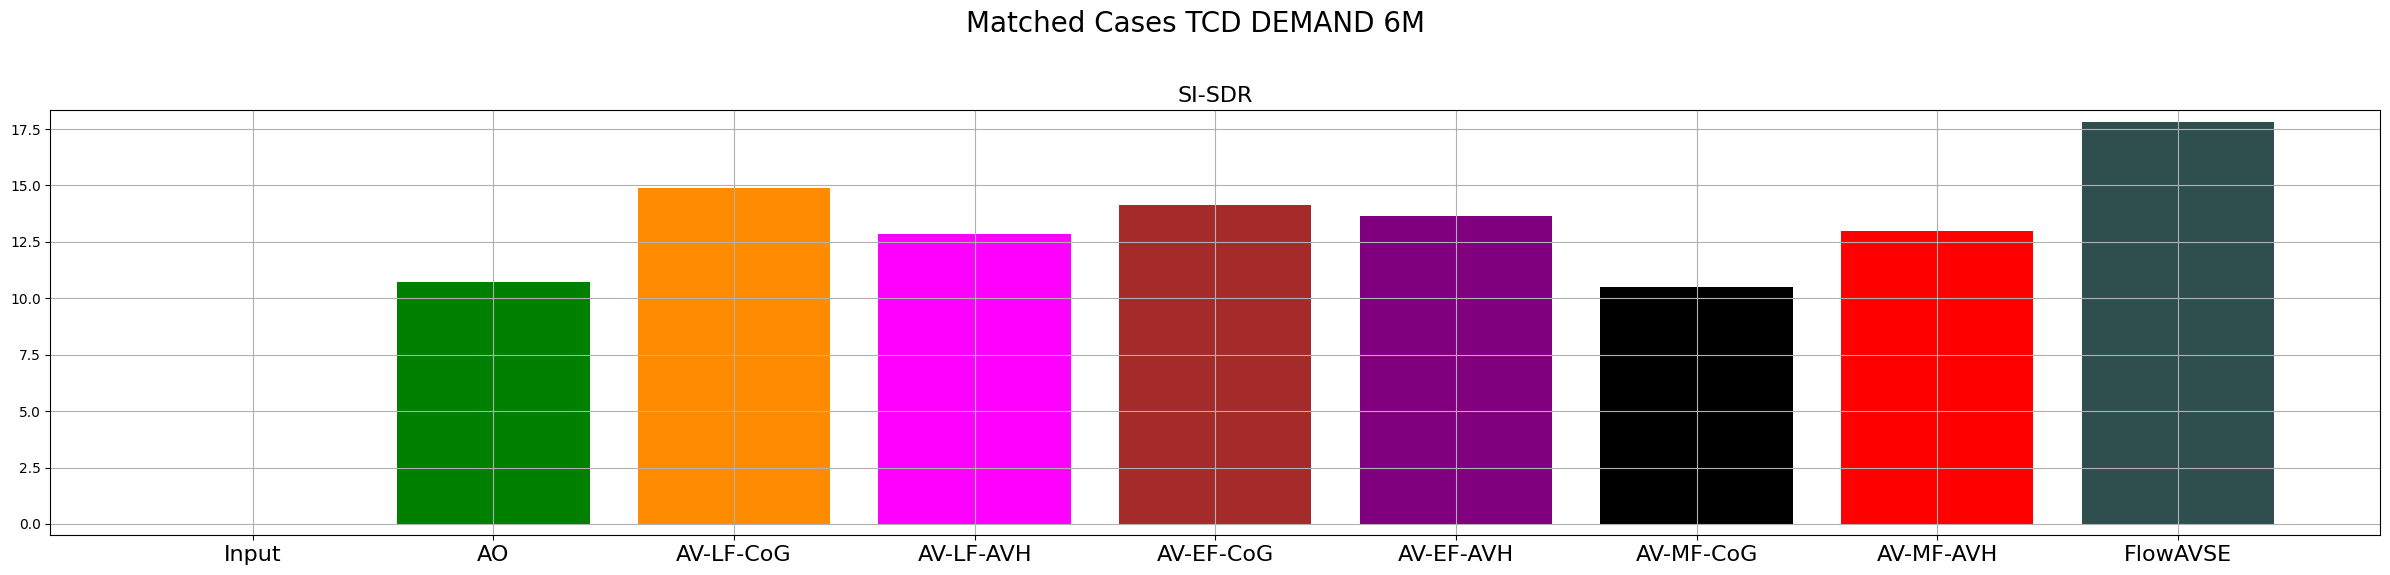

/tmp/ipykernel_3924646/74686201.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(methods, fontsize=10)


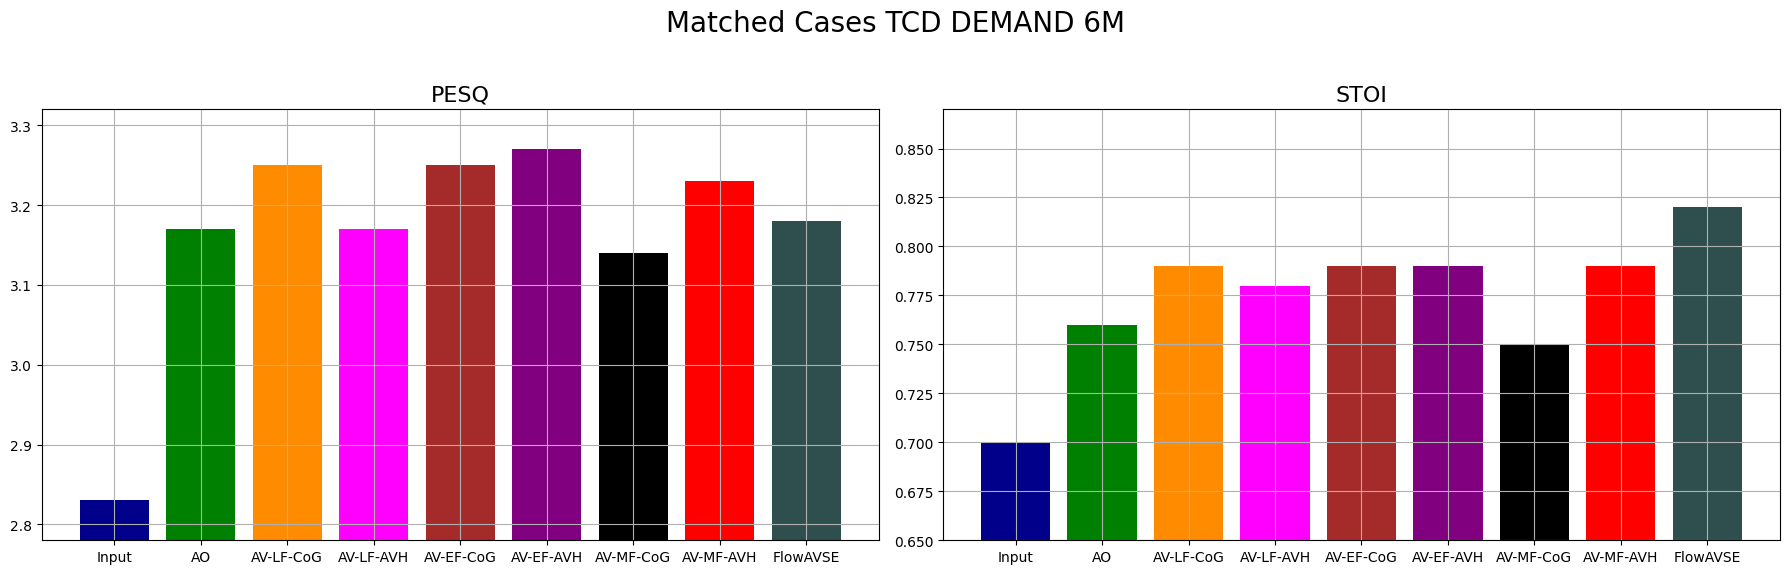

"create_figure([mismatched_sisdr, mismatched_pesq, mismatched_estoi], 'Mismatched Cases', ['SI-SDR', 'PESQ', 'ESTOI'])"

In [ ]:
# plot
import matplotlib.pyplot as plt
import numpy as np

# Data for matched and mismatched cases including FlowAVSE
methods = ['Input', 'AO', 'AV-LF-CoG', 'AV-LF-AVH', 'AV-EF-CoG', 'AV-EF-AVH' ,  'AV-MF-CoG', 'AV-MF-AVH' ,   'FlowAVSE']
matched_sisdr = [0.00, 10.72, 14.9, 12.86, 14.12 ,13.66 ,10.51, 12.99 ,  17.83]
matched_pesq = [2.83,3.17, 3.25  ,3.17, 3.25, 3.27, 3.14, 3.23,  3.18]
matched_estoi = [0.70,0.76,0.79 , 0.78 , 0.79 , 0.79, 0.75 , 0.79,0.82]


def create_figure(data, title, metrics):
    if len(metrics)>1:
            
        fig, axs = plt.subplots(1, len(metrics), figsize=(18, 6))
        fig.suptitle(title, fontsize=20)

        for i, ax in enumerate(axs):
            ax.grid(zorder=0)
            bars = ax.bar(methods, data[i], color=['darkblue', 'green', 'darkorange', 'magenta', 'brown', 'purple', 'black', 'red', 'darkslategrey' ])
            ax.set_title(metrics[i], fontsize=16)
            #ax.set_ylim([min(min(data[i])-0.05, 0), max(data[i])+0.05])
            ax.set_ylim([min(data[i])-0.05, max(data[i])+0.05])
            ax.set_xticklabels(methods, fontsize=10)
    else:
        
        fig, ax = plt.subplots(1, len(metrics), figsize=(24, 6))
        fig.suptitle(title, fontsize=20)
        ax.grid(zorder=0)
        bars = ax.bar(methods, data[0], color=['darkblue', 'green', 'darkorange', 'magenta', 'brown', 'purple', 'black', 'red', 'darkslategrey' ])
        ax.set_title(metrics[0], fontsize=16)
        ax.set_ylim([min(data[0])-0.5, max(data[0])+0.5])
        ax.set_xticklabels(methods, fontsize=16)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Matched case figure
create_figure([ matched_sisdr ], 'Matched Cases TCD DEMAND 6M', ['SI-SDR'])

#create_figure([ matched_sisdr,  matched_sisdr,  matched_sisdr ], 'Matched Cases TCD DEMAND', ['SI-SDR', 'SI-SDR', 'SI-SDR'])
create_figure([ matched_pesq, matched_estoi], 'Matched Cases TCD DEMAND 6M', [ 'PESQ', 'STOI'])


# Mismatched case figure
"""create_figure([mismatched_sisdr, mismatched_pesq, mismatched_estoi], 'Mismatched Cases', ['SI-SDR', 'PESQ', 'ESTOI'])"""


### TCD-TIMIT -> LRS3-NTCD

### LRS3 -> TCD DEMAND

In [ ]:
"Early Fusion", "CoGenAV", "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_early_fusion_cogenav_6M_LRS3_/av_diffse_early_fusion_cogenav_6M_LRS3/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"
"Late Fusion", "CoGenAV", "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_6M_LRS3_/av_diffse_late_fusion_cogenav_6M_LRS3/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv"

('Late Fusion',
 'CoGenAV',
 '/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/fast_UdiffSE_fusion/eval/results/av_diffse_late_fusion_cogenav_6M_LRS3_/av_diffse_late_fusion_cogenav_6M_LRS3/TCD-DEMAND/fudiffse_v2/1.75/fudiffse_v2/metrics.csv')

### Obsolete results : Before data loader Correction

### trained on TCD TIMIT -> test on TCD DEMAND

In [ ]:
# ['Cafe' 'Babble' 'LR' 'White' 'Car'] [ 5 -5]
# 
# all those results are using fudiffse_v2 inference on TCD DEMAND, trained on TCD TIMIT
"""cross_att_tcd = {
#"ao" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/msadeghi/pytorch/SE-Diffusion/diffuse/eval/results/last/TCD-TIMIT/fudiffse_v2_av/AO_newTCDtest_6M_normal_lmbd175_scheduler/metrics.csv",
#"ao" : "../../../se_results/av_diff_cogenav_before_transformer_score_model/av_contrast_cogenav_before_transformer_score_model/TCD-DEMAND/fudiffse/1.5/fudiffuse_bs4/metrics.csv",
#"av" :"/srv/storage/talc3@storage4.nancy/multispeech/calcul/users/cmboungo/se_results/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_p0_28M_enc_dec/logs/TCD-DEMAND/fudiffse_v2/1.75/origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att": "../results/av_cross_att/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_zero" : "../results/av_diffse_cross_att_avhubert_zero/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_random" : "../results/av_diffse_cross_att_avhubert_random/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_2heads":                 "../results/av_diffse_cross_att_avhubert_2heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_4heads":                 "../results/av_diffse_cross_att_avhubert_4heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_cogenav_before_transformer" : "../results/av_cross_att_cogenav_before_transformer/epoch=219-last-v1/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_cogenav_before_transformer_2heads" : "../results/av_diffse_cross_att_cogenav_before_2heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_cogenav_after_transformer" : "../results/av_cross_att_cogenav_after_transformer/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"av_cross_att_cogenav_concat_before_after" : "../results/av_diffse_cross_att_cogenav_concat_before_after/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"
}"""

cross_att_tcd = {
"AV" : {"fusion": "Late Cross Attention" , "visual embedding" : "CoGenAV Before Transformer", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_contrast_cogenav_before_transformer_score_model_fudiffse_v2_av/av_contrast_cogenav_before_transformer_score_model/TCD-DEMAND/fudiffse_v2/1.75/A0_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV ": {"fusion": "Early Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" :"../results/av_cross_att/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
#"AV  " : {"fusion": "Early Cross Attention" , "visual embedding" : "Zero", "filepath" :"../results/av_diffse_cross_att_avhubert_zero/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
#"AV   " :{"fusion": "Early Cross Attention" , "visual embedding" : "Random", "filepath" : "../results/av_diffse_cross_att_avhubert_random/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV    ":{"fusion": "Early Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" : "../results/av_diffse_cross_att_avhubert_2heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV     ":{"fusion": "Early Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" : "../results/av_diffse_cross_att_avhubert_4heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV      " : {"fusion": "Early Cross Attention" , "visual embedding" : "CoGenAV Before Transformer", "filepath" : "../results/av_cross_att_cogenav_before_transformer/epoch=219-last-v1/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV       " : {"fusion": "Early Cross Attention" , "visual embedding" : "CoGenAV Before Transformer", "filepath" :"../results/av_diffse_cross_att_cogenav_before_2heads/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV        " :{"fusion": "Early Cross Attention" , "visual embedding" : "CoGenAV After Transformer", "filepath" : "../results/av_cross_att_cogenav_after_transformer/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV         " : {"fusion": "Early Cross Attention" , "visual embedding" : "CoGenAV Concat Before+After Transformer", "filepath" :"../results/av_diffse_cross_att_cogenav_concat_before_after/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV          " : {"fusion":"Mixed Fusion",  "visual embedding" : "AV-HUBERT", "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_diff_mixed_fusion_av_hubert_pre_28M/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV           " : {"fusion":"Late Fusion",  "visual embedding" : "CoGenAV", "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_contrast_cogenav_before_transformer_score_model_corrected/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},

}
cross_att_tcd_df = display_df1(cross_att_tcd) #, metric_mode="mean", snr_min = -15, snr_max = 15)

display(cross_att_tcd_df)



,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
AV,Late Cross Attention,CoGenAV Before Transformer,10.09 ± 0.3,16.41 ± 0.49,14.33 ± 0.21,3.19 ± 0.02,0.77 ± 0.01
AV,Early Cross Attention,AV-HUBERT,11.72 ± 0.26,20.61 ± 0.51,14.63 ± 0.2,3.23 ± 0.02,0.77 ± 0.01
AV,Early Cross Attention,AV-HUBERT,12.61 ± 0.24,23.82 ± 0.52,14.71 ± 0.18,3.28 ± 0.02,0.78 ± 0.01
AV,Early Cross Attention,AV-HUBERT,11.91 ± 0.26,21.36 ± 0.51,14.48 ± 0.2,3.26 ± 0.02,0.78 ± 0.01
AV,Early Cross Attention,CoGenAV Before Transformer,13.25 ± 0.26,23.7 ± 0.49,15.12 ± 0.21,3.25 ± 0.02,0.79 ± 0.0
AV,Early Cross Attention,CoGenAV Before Transformer,14.59 ± 0.22,26.96 ± 0.45,15.8 ± 0.19,3.28 ± 0.02,0.79 ± 0.0
AV,Early Cross Attention,CoGenAV After Transformer,10.33 ± 0.3,17.91 ± 0.52,13.9 ± 0.22,3.24 ± 0.02,0.77 ± 0.01
AV,Early Cross Attention,CoGenAV Concat Before+After Transformer,10.51 ± 0.29,17.87 ± 0.51,14.44 ± 0.21,3.19 ± 0.02,0.76 ± 0.01
AV,Mixed Fusion,AV-HUBERT,7.71 ± 0.31,13.56 ± 0.5,12.54 ± 0.22,3.16 ± 0.02,0.75 ± 0.01
AV,Late Fusion,CoGenAV,7.6 ± 0.3,12.3 ± 0.44,12.74 ± 0.22,3.13 ± 0.02,0.75 ± 0.01


In [ ]:

cross_att_lrs3_lrs3_ntcd = {
"Input LRS3-NTCD":  {
    "fusion" : "",
    "visual embedding":"",
    "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/AOLRS3_LRS3_NTCD/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/input_metrics.csv"
    },

   
"AO (6M)":  {
    "fusion" : "",
    "visual embedding":"",
    "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/AOLRS3_LRS3_NTCD/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"
    },

"AV-UDiffSE (6M)": {

"fusion" : "Early Fusion 2 Heads",
"visual embedding":"AV-HUBERT",
"filepath": "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_diffse_cross_att_2_heads_avhubert_lrs3/epoch=202-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"
},

}

cross_att_lrs3_lrs3_ntcd_df = display_df1(cross_att_lrs3_lrs3_ntcd, metric_mode="mean", snr_min = -15, snr_max = 15)
display(cross_att_lrs3_lrs3_ntcd_df)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input LRS3-NTCD,,,0.03 ± 0.14,0.03 ± 0.14,44.29 ± 0.32,2.1 ± 0.02,0.58 ± 0.01
AO (6M),,,2.36 ± 0.16,2.85 ± 0.17,12.93 ± 0.12,2.33 ± 0.02,0.63 ± 0.01
AV-UDiffSE (6M),Early Fusion 2 Heads,AV-HUBERT,4.13 ± 0.18,7.34 ± 0.26,9.81 ± 0.14,2.6 ± 0.02,0.68 ± 0.01


### NTCD-TIMIT TEST5 : more extreme SNR conditions

In [ ]:
tcd_test5 = {
"Input NTCD-TIMIT Test 5" : {"fusion": "", "visual embedding":"", "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/aonly_tcd_speech_modeling_default_28M_test5/logs/TCD-DEMAND/fudiffse_v2/1.75/origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/input_metrics.csv"},
"AO" : {"fusion": "", "visual embedding":"", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/diffuse/eval/results/AO_local_ckpt_test_data_5/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV-HUBERT + Early Fusion" : {"fusion": "Early Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/diffuse/eval/results/av_diffse_cross_att_avhubert_1head_test_data_5/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"AV-HUBERT + Early Fusion ": {"fusion": "Early Cross Attention 2 heads", "visual embedding" : "AV-HUBERT", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/diffuse/eval/results/av_diffse_cross_att_avhubert_2heads_test_data_5/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"CoGenAV + Early Fusion" : {"fusion": "Early Cross Attention" , "visual embedding" : "CoGenAV Before Transformer", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/diffuse/eval/results/av_diffse_cross_att_cogenav_before_1head_test_data_5/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"CoGenAV + Early Fusion ": {"fusion": "Early Cross Attention 2 heads" , "visual embedding" : "CoGenAV Before Transformer", "filepath" :"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/diffuse/eval/results/av_diffse_cross_att_cogenav_before_2heads_test_data_5/epoch=219-last/TCD-DEMAND/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
#"AV-HUBERT + Late Fusion" : {"fusion": "Late Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_pre_p0_28M_enc_dec_test5/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_pre_p0_28M_enc_dec_/TCD-TIMIT/fudiffse_v2/1.75/A0_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"}, 
"AV-HUBERT + Late Fusion  " : {"fusion": "Late Cross Attention" , "visual embedding" : "AV-HUBERT", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_p0_28M_enc_dec_test5_github/logs/TCD-TIMIT/fudiffse_v2/1.75/A0_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
"CoGenAV + Late Fusion  " : {"fusion": "Late Cross Attention" , "visual embedding" : "CoGenAV Before Transformer", "filepath" : "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_contrast_cogenav_before_transformer_test5/av_contrast_cogenav_before_transformer_score_model/TCD-TIMIT/fudiffse_v2/1.75/A0_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"},
}
tcd_test5_df = display_df1(tcd_test5)
display(tcd_test5_df)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input NTCD-TIMIT Test 5,,,-7.81 ± 0.22,-7.76 ± 0.22,40.64 ± 0.54,1.77 ± 0.02,0.31 ± 0.0
AO,,,0.61 ± 0.25,4.34 ± 0.3,4.16 ± 0.23,2.21 ± 0.02,0.43 ± 0.01
AV-HUBERT + Early Fusion,Early Cross Attention,AV-HUBERT,2.04 ± 0.23,9.99 ± 0.45,4.55 ± 0.2,2.29 ± 0.02,0.42 ± 0.01
AV-HUBERT + Early Fusion,Early Cross Attention 2 heads,AV-HUBERT,2.9 ± 0.23,13.17 ± 0.47,4.45 ± 0.19,2.35 ± 0.02,0.43 ± 0.01
CoGenAV + Early Fusion,Early Cross Attention,CoGenAV Before Transformer,3.99 ± 0.22,13.73 ± 0.47,5.86 ± 0.19,2.27 ± 0.02,0.44 ± 0.01
CoGenAV + Early Fusion,Early Cross Attention 2 heads,CoGenAV Before Transformer,2.84 ± 0.23,13.07 ± 0.47,4.39 ± 0.19,2.35 ± 0.02,0.43 ± 0.01
AV-HUBERT + Late Fusion,Late Cross Attention,AV-HUBERT,3.89 ± 0.23,11.69 ± 0.41,6.0 ± 0.2,2.33 ± 0.02,0.5 ± 0.01
CoGenAV + Late Fusion,Late Cross Attention,CoGenAV Before Transformer,-2.22 ± 0.25,-0.14 ± 0.26,3.15 ± 0.25,2.09 ± 0.02,0.41 ± 0.01


## Matched Conditions LRS3
### training on LRS3 , evaluation on LRS3-NTCD

In [ ]:



print(len(pd.read_csv("/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/ICP_52_results/grat/LRS3-NTCD/audio_only_sgmse_lrs3_ntcd_28M/input_metrics.csv")))
print(len(pd.read_csv("/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/AOLRS3_LRS3_NTCD/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv")))

1321
1321


### MISmatched Trained on TCD-TIMIT : Test on LRS3_NTCD

In [ ]:
# all those results are using fudiffse_v2 inference on LRS3, trained on TCD TIMIT
cross_att_lrs3 = {
"AVDiffSE (6M)":  {
    "fusion" : "Early Fusion 2 heads",
    "visual embedding":"AV-HUBERT",
    "filepath":"../results/av_diffse_cross_att_avhubert_2heads_lrs3/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"
    },

"AVDiffSE (32M)":  {
    "fusion" : "Mixed Fusion 2 heads",
    "visual embedding":"AV-HUBERT",
    "filepath":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/cmboungo/se_results/av_diff_mixed_fusion_avhubert_28M/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv"
    },

}
cross_att_lrs3_df = display_df1(cross_att_lrs3, metric_mode="mean", snr_min = -15, snr_max = 15)
display(cross_att_lrs3_df)

FileNotFoundError: [Errno 2] No such file or directory: '../results/av_diffse_cross_att_avhubert_2heads_lrs3/epoch=219-last/LRS3-NTCD/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv'

In [ ]:


# raw values copied from Jean-Eudes's fudiffse_v2 table
concat_att_lrs3 = {
    "Input LRS3-NTCD": {
        "fusion": "", "visual embedding" : "","SI-SDR ± SE": "0.03 ± 0.14", "SI-SIR ± SE": "0.03 ± 0.14", "SI-SAR ± SE": "44.29 ± 0.32", "PESQ ± SE": "2.1 ± 0.02", "STOI ± SE": "0.58 ± 0.01"
    },
    "AO (28M)": {
        "fusion": "", "visual embedding" : "","SI-SDR ± SE": "5.35 ± 0.18", "SI-SIR ± SE": "8.88 ± 0.24", "SI-SAR ± SE": "9.14 ± 0.14", "PESQ ± SE": "2.48 ± 0.02", "STOI ± SE": "0.66 ± 0.01"
    },
    "AVDiffSE (28M)": {
        "fusion": "Late Cross Attention", "visual embedding" : "AV-HUBERT","SI-SDR ± SE": "7.36 ± 0.17", "SI-SIR ± SE": "15.38 ± 0.3", "SI-SAR ± SE": "9.03 ± 0.15", "PESQ ± SE": "2.61 ± 0.02", "STOI ± SE": "0.69 ± 0.00"
    }}

    

concat_att_lrs3_df = pd.DataFrame.from_dict(concat_att_lrs3, orient="index")

flow_avse_lrs3 = {
    
    "FlowAVSE (60M)": {
        "fusion": "", "visual embedding" : "","SI-SDR ± SE": "3.12 ± 0.23", "SI-SIR ± SE": "21.24 ± 0.32", "SI-SAR ± SE": "3.28 ± 0.23", "PESQ ± SE": "1.49 ± 0.02", "STOI ± SE": "0.53 ± 0.01"
   }}
flow_avse_lrs3_df = pd.DataFrame.from_dict(flow_avse_lrs3, orient="index")
# Display nicely in Jupyter
#display(concat_att_lrs3_df)


combined_lrs3_df = pd.concat([concat_att_lrs3_df, experiments_tcd_lrs3_ntcd_df, flow_avse_lrs3_df]) #, cross_att_lrs3_df
# Append the data frame's row to the combined results DataFrame




display(combined_lrs3_df)

,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input LRS3-NTCD,,,0.03 ± 0.14,0.03 ± 0.14,44.29 ± 0.32,2.1 ± 0.02,0.58 ± 0.01
AO (28M),,,5.35 ± 0.18,8.88 ± 0.24,9.14 ± 0.14,2.48 ± 0.02,0.66 ± 0.01
AVDiffSE (28M),Late Cross Attention,AV-HUBERT,7.36 ± 0.17,15.38 ± 0.3,9.03 ± 0.15,2.61 ± 0.02,0.69 ± 0.00
"AV InfoNCE loss Warmup = 100 ep, alpha0 = 5000 (6M)",Late Fusion,AVHUBERT (On the Fly),4.47 ± 0.28,17.63 ± 0.62,5.83 ± 0.24,2.33 ± 0.02,0.46 ± 0.01
FlowAVSE (60M),,,3.12 ± 0.23,21.24 ± 0.32,3.28 ± 0.23,1.49 ± 0.02,0.53 ± 0.01


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input LRS3-NTCD,,,0.03 ± 0.14,0.03 ± 0.14,44.29 ± 0.32,2.1 ± 0.02,0.58 ± 0.01
AO (28M),,,5.35 ± 0.18,8.88 ± 0.24,9.14 ± 0.14,2.48 ± 0.02,0.66 ± 0.01
AVDiffSE (28M),Late Cross Attention,AV-HUBERT,7.36 ± 0.17,15.38 ± 0.3,9.03 ± 0.15,2.61 ± 0.02,0.69 ± 0.00
AVDiffSE,Early Fusion 2 heads,AV-HUBERT,7.11 ± 0.18,16.51 ± 0.33,8.73 ± 0.16,2.61 ± 0.02,0.67 ± 0.01
AVDiffSE,Mixed Fusion 2 heads,AV-HUBERT,4.6 ± 0.17,8.25 ± 0.22,8.08 ± 0.15,2.4 ± 0.02,0.65 ± 0.01
FlowAVSE (60M),,,3.12 ± 0.23,21.24 ± 0.32,3.28 ± 0.23,1.49 ± 0.02,0.53 ± 0.01


In [ ]:
# TCD DEMAND evaluation

# raw values copied from Jean-Eudes's fudiffse_v2 table 
concat_att_tcd = {
    "Input TCD DEMAND": {
        "fusion": "", "visual embedding" : "AV-HUBERT", "SI-SDR ± SE": "-0.0 ± 0.17", "SI-SIR ± SE": "-0.0 ± 0.17", "SI-SAR ± SE": "55.73 ± 0.4", "PESQ ± SE": "2.83 ± 0.02", "STOI ± SE": "0.7 ± 0.01"
    },
    "AO": {
        "fusion": "", "visual embedding" : "AV-HUBERT", "SI-SDR ± SE": "11.09 ± 0.28", "SI-SIR ± SE": "18.04 ± 0.48", "SI-SAR ± SE": "14.81 ± 0.2", "PESQ ± SE": "3.21 ± 0.02", "STOI ± SE": "0.78 ± 0.01"
    },
    "AV (28M)": {
        "fusion": "Late Cross Attention", "visual embedding" : "AV-HUBERT", "SI-SDR ± SE": "13.39 ± 0.24", "SI-SIR ± SE": "23.35 ± 0.48", "SI-SAR ± SE": "15.39 ± 0.2", "PESQ ± SE": "3.28 ± 0.02", "STOI ± SE": "0.81 ± 0.00"
    },}
concat_att_tcd_df = pd.DataFrame.from_dict(concat_att_tcd, orient="index")

# Display nicely in Jupyter
display(concat_att_tcd_df)

flow_avse_tcd = {

    "AV (6M)": {
        "fusion": "Late", "visual embedding" : "CoGenAV Before", "SI-SDR ± SE": "13.04 ± 0.24", "SI-SIR ± SE": "23.16 ± 0.49", "SI-SAR ± SE": "15.02 ± 0.2", "PESQ ± SE": "3.23 ± 0.02", "STOI ± SE": "0.78 ± 0.01"
    },    
    "AV (6M) ": {
        "fusion": "Mixed 1 head", "visual embedding" : "CoGenAV Before", "SI-SDR ± SE": "10.72 ± 0.28", "SI-SIR ± SE": "18.61 ± 0.5", "SI-SAR ± SE": "13.92 ± 0.21", "PESQ ± SE": "3.18 ± 0.02", "STOI ± SE": "0.77 ± 0.01"
    },
    "AV (6M)  ": {
        "fusion": "Mixed 2 heads", "visual embedding" : "CoGenAV Before", "SI-SDR ± SE": "10.72 ± 0.28", "SI-SIR ± SE": "18.61 ± 0.5", "SI-SAR ± SE": "13.92 ± 0.21", "PESQ ± SE": "3.18 ± 0.02", "STOI ± SE": "0.77 ± 0.01"
    },
    "FlowAVSE (60M)": {
        "fusion": "", "visual embedding" : "", "SI-SDR ± SE": "13.65 ± 0.23", "SI-SIR ± SE": "24.64 ± 0.48", "SI-SAR ± SE": "15.34 ± 0.19", "PESQ ± SE": "3.22 ± 0.02", "STOI ± SE": "0.79 ± 0.01"
    }}
flow_avse_tcd_df = pd.DataFrame.from_dict(flow_avse_tcd, orient="index")
display(flow_avse_tcd_df)


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD DEMAND,,AV-HUBERT,-0.0 ± 0.17,-0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AO,,AV-HUBERT,11.09 ± 0.28,18.04 ± 0.48,14.81 ± 0.2,3.21 ± 0.02,0.78 ± 0.01
AV (28M),Late Cross Attention,AV-HUBERT,13.39 ± 0.24,23.35 ± 0.48,15.39 ± 0.2,3.28 ± 0.02,0.81 ± 0.00


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
AV (6M),Late,CoGenAV Before,13.04 ± 0.24,23.16 ± 0.49,15.02 ± 0.2,3.23 ± 0.02,0.78 ± 0.01
AV (6M),Mixed 1 head,CoGenAV Before,10.72 ± 0.28,18.61 ± 0.5,13.92 ± 0.21,3.18 ± 0.02,0.77 ± 0.01
AV (6M),Mixed 2 heads,CoGenAV Before,10.72 ± 0.28,18.61 ± 0.5,13.92 ± 0.21,3.18 ± 0.02,0.77 ± 0.01
FlowAVSE (60M),,,13.65 ± 0.23,24.64 ± 0.48,15.34 ± 0.19,3.22 ± 0.02,0.79 ± 0.01


In [ ]:
# Append the data frame's row to the combined results DataFrame



combined_tcd_df = pd.concat([concat_att_tcd_df, cross_att_tcd_df, flow_avse_tcd_df ])
display(combined_tcd_df)


,fusion,visual embedding,SI-SDR ± SE,SI-SIR ± SE,SI-SAR ± SE,PESQ ± SE,STOI ± SE
Input TCD DEMAND,,AV-HUBERT,-0.0 ± 0.17,-0.0 ± 0.17,55.73 ± 0.4,2.83 ± 0.02,0.7 ± 0.01
AO,,AV-HUBERT,11.09 ± 0.28,18.04 ± 0.48,14.81 ± 0.2,3.21 ± 0.02,0.78 ± 0.01
AV (28M),Late Cross Attention,AV-HUBERT,13.39 ± 0.24,23.35 ± 0.48,15.39 ± 0.2,3.28 ± 0.02,0.81 ± 0.00
AV,Late Cross Attention,CoGenAV Before Transformer,10.09 ± 0.3,16.41 ± 0.49,14.33 ± 0.21,3.19 ± 0.02,0.77 ± 0.01
AV,Early Cross Attention,AV-HUBERT,11.72 ± 0.26,20.61 ± 0.51,14.63 ± 0.2,3.23 ± 0.02,0.77 ± 0.01
AV,Early Cross Attention,AV-HUBERT,12.61 ± 0.24,23.82 ± 0.52,14.71 ± 0.18,3.28 ± 0.02,0.78 ± 0.01
AV,Early Cross Attention,AV-HUBERT,11.91 ± 0.26,21.36 ± 0.51,14.48 ± 0.2,3.26 ± 0.02,0.78 ± 0.01
AV,Early Cross Attention,CoGenAV Before Transformer,13.25 ± 0.26,23.7 ± 0.49,15.12 ± 0.21,3.25 ± 0.02,0.79 ± 0.0
AV,Early Cross Attention,CoGenAV Before Transformer,14.59 ± 0.22,26.96 ± 0.45,15.8 ± 0.19,3.28 ± 0.02,0.79 ± 0.0
AV,Early Cross Attention,CoGenAV After Transformer,10.33 ± 0.3,17.91 ± 0.52,13.9 ± 0.22,3.24 ± 0.02,0.77 ± 0.01


: 

: 

: 

In [ ]:
# TO FIX
mean_per_group(cross_att_tcd_df, group = "snr" , colormax=0)  

TypeError: argument of type 'method' is not iterable

In [ ]:
import pandas as pd

df = pd.read_csv(list(params.values())[3])
print(df["Noise SNR"].unique())


[ 5 -5]


: 

: 

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# df_per_group is the multi-index dataframe from mean_per_group
df_long = df_per_group.stack(level=[0,1]).reset_index()
df_long.columns = ["Model", "Metric", "SNR", "Value"]

# Plot: one subplot per metric
g = sns.FacetGrid(df_long, col="Metric", sharey=False, height=4, aspect=1.5)
g.map_dataframe(sns.lineplot, x="SNR", y="Value", hue="Model", marker="o")

g.add_legend()
plt.show()



NameError: name 'df_per_group' is not defined

: 

: 

: 

In [ ]:
params = {
"Input (TCD)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AO_6M_normal_lmbd175_scheduler/input_metrics.csv",
"fUDiffSE_v2_AO (6M, bs4)": "../results/epoch=199-last/TCD-TIMIT/fudiffse_v2/AO_TCD_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_AO (28M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_28M_lmbd175_pjc2/metrics.csv",
"fUDiffSE_v2_av_AO (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AO_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_res (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_TCD_6M_Hu_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_25fps (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest540_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest540_fps30_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_new (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_6M_normal_lmbd175_scheduler_old/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_new2 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk10 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk10_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk10_strip (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk10_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk05_strip (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_strip_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk05 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk05_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk20 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk20_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_30fps_corr_msk00_outlayer (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps30cor_msk00_outlayer_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_25fps_corr (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_origTCDtest_fps25_6M_normal_lmbd175_scheduler/metrics.csv",
"fUDiffSE_v2_av_AV_Hu_25fps_cfg1 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2_av/AV_CFG_origTCDtest540_6M_normal_lmbd175_scheduler_w1/metrics.csv",

}
display_df(params, metric_mode="mean", snr_min = -5, snr_max = 5)

,SI-SDR ± SE,PESQ ± SE,STOI ± SE
Input (TCD),-7.43 ± 0.31,1.9 ± 0.02,0.36 ± 0.01
"fUDiffSE_v2_AO (6M, bs4)",-0.58 ± 0.42,2.35 ± 0.02,0.45 ± 0.01
"fUDiffSE_v2_AO (28M, bs4)",-1.4 ± 0.35,2.16 ± 0.02,0.43 ± 0.01
"fUDiffSE_v2_av_AO (6M, bs4)",0.86 ± 0.32,2.3 ± 0.02,0.46 ± 0.01
"fUDiffSE_v2_av_AV_res (6M, bs4)",3.9 ± 0.31,2.38 ± 0.02,0.49 ± 0.01
"fUDiffSE_v2_av_AV_Hu (6M, bs4)",4.88 ± 0.3,2.37 ± 0.02,0.49 ± 0.01
"fUDiffSE_v2_av_AV_Hu_25fps (6M, bs4)",5.22 ± 0.28,2.41 ± 0.02,0.47 ± 0.01
"fUDiffSE_v2_av_AV_Hu_30fps_corr (6M, bs4)",4.92 ± 0.3,2.39 ± 0.02,0.48 ± 0.01
"fUDiffSE_v2_av_AV_Hu_30fps_corr_new (6M, bs4)",3.61 ± 0.29,2.4 ± 0.02,0.48 ± 0.01
"fUDiffSE_v2_av_AV_Hu_30fps_corr_new2 (6M, bs4)",3.34 ± 0.29,2.39 ± 0.02,0.48 ± 0.01


: 

: 

: 

In [ ]:
params = {
    "fUDiffSE_v2-190 (6M)": "../results/epoch=199-last/TCD-DEMAND/fudiffse_v2/non_linear_new_6M_lmbd190_pjc2/metrics.csv",
    "fUdiffSE-v2-175 (28M)": "../results/epoch=199-last/TCD-DEMAND/fudiffse_v2/non_linear_JE_28M_lmbd175_pjc2/metrics.csv",
}
display_df(params, metric_mode="mean", snr_min = -5, snr_max = 5)


,SI-SDR ± SE,PESQ ± SE,STOI ± SE,MOS_SIG ± SE,MOS_BAK ± SE,MOS_OVR ± SE
fUDiffSE_v2-190 (6M),11.03 ± 0.28,3.22 ± 0.02,0.77 ± 0.01,4.01 ± 0.01,3.94 ± 0.01,3.47 ± 0.01
fUdiffSE-v2-175 (28M),9.71 ± 0.29,3.26 ± 0.02,0.76 ± 0.01,3.98 ± 0.01,3.97 ± 0.01,3.43 ± 0.01


: 

: 

: 

In [ ]:
params = {
    "Input (WSJ0)": "/srv/storage/talc@storage4.nancy.grid5000.fr/multispeech/corpus/audio_visual/results_tmp_diff/audio_only_wsj0/input_metrics.csv",
    # "SGMSE (65M)":"/srv/storage/talc@storage4.nancy.grid5000.fr/multispeech/corpus/audio_visual/results_tmp_diff/audio_only_wsj0/metrics.csv",
    "SGMSE (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_wsj0_6M/metrics.csv",
    "Supervised (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_wsj0_supervised_withprogressive_6M/metrics.csv",
    # "ParaDiffUSE (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_orig_bs8_lmbd225/metrics.csv",
    # "ParaDiffUSE-wnold (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_orig_bs8_lmbd225_wiener/metrics.csv",
    # "ParaDiffUSE-old (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_orig_bs8_lmbd225_noise1e3/metrics.csv",
    # "ParaDiffUSE (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_orig_bs8_lmbd225_nocorrection/metrics.csv",
    # "ParaDiffUSE (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_wn_new/metrics.csv",
    # "ParaDiffUSE-saw-tooth (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_saw_tooth_lmbd175/metrics.csv",
    # "ParaDiffUSE-linear (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_saw_tooth_max_step99/metrics.csv",
    "ParaDiffUSE-sigma (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_sigma_lmbd575/metrics.csv",
    # "ParaDiffUSE-sigma-refine (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_sigma_lmbd575_refine27/metrics.csv",
    # "ParaDiffUSE-saw-tooth-orth (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_saw_tooth_ortho/metrics.csv",
    # "ParaDiffUSE-bs4 (6M)": "../results/last/WSJ0/paradiffuse/non_linear_new_6M_orig_bs4_lmbd225/metrics.csv",
    "UDiffSE (65M)": "../results/diffusion_gen_nonlinear_transform/WSJ0/udiffse/diffusion_gen_nonlinear_transform/metrics.csv",
    "UDiffSE (6M)": "../results/last/WSJ0/udiffse/non_linear_new_6M_lmbd150_pjc2/metrics.csv",
    "fUdiffSE (6M)": "../results/last/WSJ0/fudiffse/non_linear_trmean_6M_orig_bs8/metrics.csv",
    # "fUdiffSE-v2-375 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd375/metrics.csv",
    # "fUdiffSE-v2-425 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd425/metrics.csv",
    # "fUdiffSE-v2-450 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd450/metrics.csv",
    # "fUdiffSE-v2-475 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd475/metrics.csv",
    # "fUdiffSE-v2-525 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd525/metrics.csv",
    # "fUdiffSE-v2-475-tcd (6M)": "../results/epoch=199-last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd475_tcd/metrics.csv",
    # "fUdiffSE-v2-150-pjc2 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd150_pjc2/metrics.csv",
    "fUdiffSE-v2-175-pjc2 (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd175_pjk2/metrics.csv",
    "fUdiffSE-v2-175-pjc2-wc (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd175_pjc2_wc/metrics.csv",
    "fUdiffSE-v2-150-pjc2-wc (6M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_lmbd150_pjc2_wc/metrics.csv",
    "fUdiffSE-v2-175-pjc2 (12M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_12M_lmbd175_pjc2/metrics.csv",
    "fUdiffSE-v2-175-pjc2 (28M)": "../results/last/WSJ0/fudiffse_v2/non_linear_new_28M_lmbd175_pjc2/metrics.csv",
    "fUdiffSE-v2-adalmbd (6M)" : "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_adalmbd_wc/metrics.csv",
    "fUdiffSE-v2-adalmbd5 (6M)" : "../results/last/WSJ0/fudiffse_v2/non_linear_new_6M_adalmbd5_wc/metrics.csv",
    # "fUdiffSE-nc (6M)": "../results/last/WSJ0/fudiffse/non_linear_new_6M_nocorrector/metrics.csv",
    # "fUdiffSE-saw (6M)": "../results/epoch=199-last/WSJ0/fudiffse/non_linear_new_6M_saw_tooth_lmbd225/metrics.csv",
}
display_df(params, metric_mode="median", snr_min = -5, snr_max = 5)


,SI-SDR ± SE,PESQ ± SE,STOI ± SE
Input (WSJ0),-2.57 ± 0.16,1.81 ± 0.02,0.49 ± 0.01
SGMSE (6M),9.01 ± 0.17,2.7 ± 0.02,0.79 ± 0.0
Supervised (6M),12.44 ± 0.14,2.65 ± 0.02,0.83 ± 0.0
ParaDiffUSE-sigma (6M),9.81 ± 0.16,2.8 ± 0.02,0.79 ± 0.0
UDiffSE (65M),5.86 ± 0.23,2.3 ± 0.02,0.64 ± 0.01
UDiffSE (6M),5.54 ± 0.26,2.22 ± 0.02,0.63 ± 0.01
fUdiffSE (6M),5.32 ± 0.21,2.33 ± 0.02,0.62 ± 0.01
fUdiffSE-v2-175-pjc2 (6M),7.33 ± 0.19,2.53 ± 0.02,0.72 ± 0.01
fUdiffSE-v2-175-pjc2-wc (6M),7.18 ± 0.22,2.46 ± 0.02,0.72 ± 0.01
fUdiffSE-v2-150-pjc2-wc (6M),7.55 ± 0.22,2.5 ± 0.02,0.72 ± 0.01


: 

: 

: 

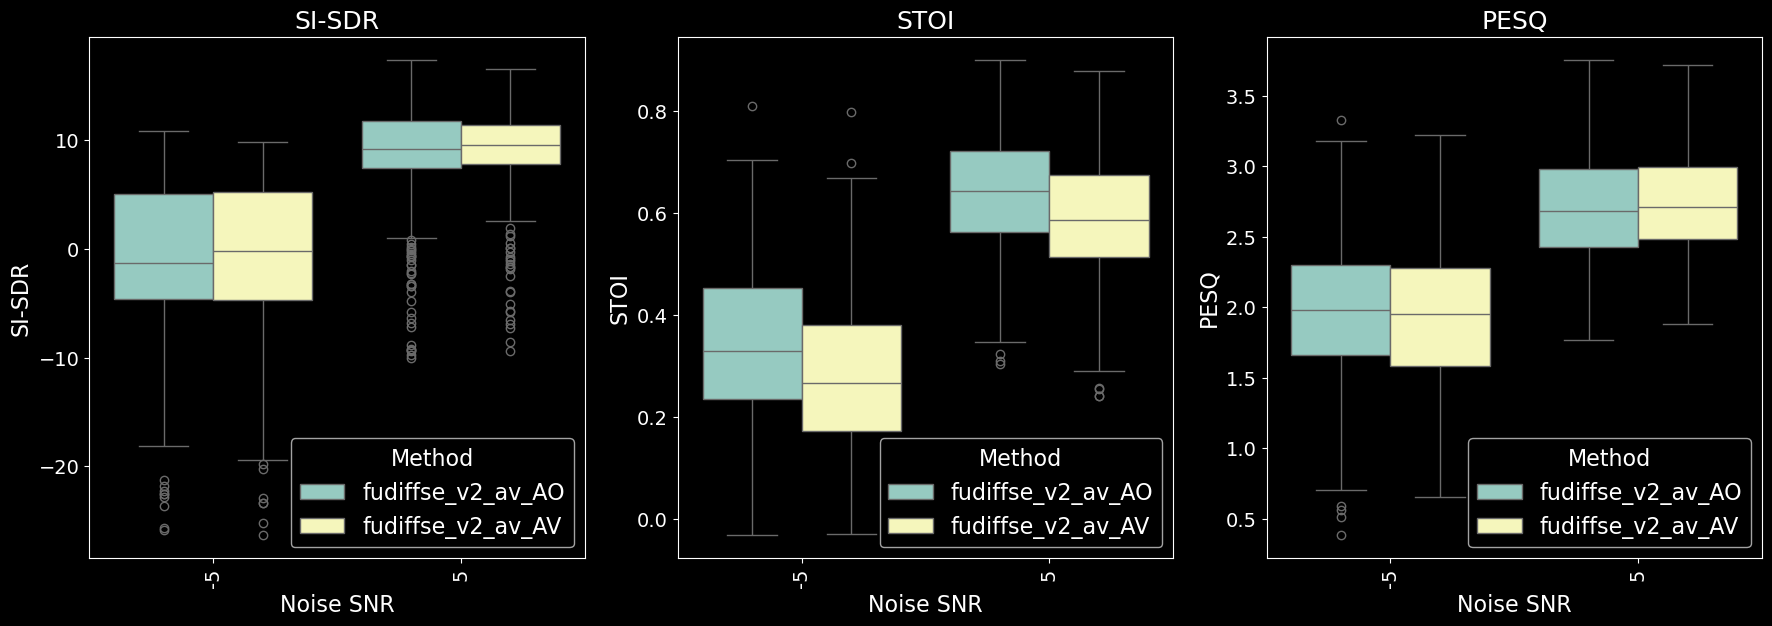

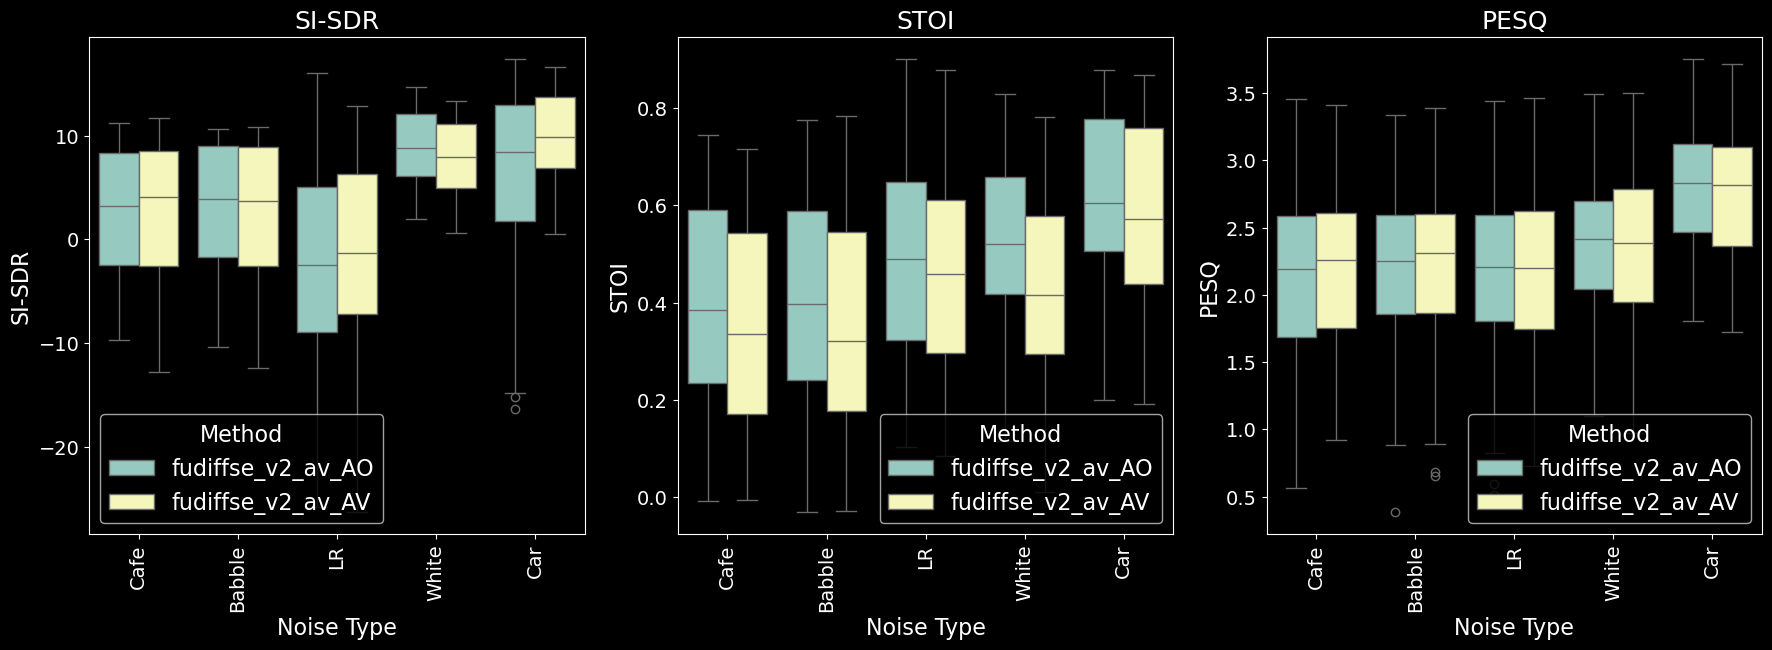

: 

: 

: 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# file_path_new_1 = "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/ICP_52_results/grat/TCD-TIMIT/GTA_aonly_tcd_speech_modeling_default_28M/TCD-TIMIT/fudiffse_v2/fudiffse_v2_bs4/metrics.csv"
file_path_new_1 = "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/ICP_52_results/with_corrector/TCD-TIMIT/av_tcd_speech_modeling_concat_attn_masking_light_avhubert_p0_28M_enc_dec/TCD-TIMIT/fudiffse_v2/1.75/fudiffse_v2_bs4/metrics.csv"

# Load the first new CSV file
# file_path_new_1 = '../results/last/TCD-TIMIT/fudiffse_v2_av/AO_newTCDtest_6M_normal_lmbd175_scheduler/metrics.csv'
df_new_1 = pd.read_csv(file_path_new_1)

# Load the second new CSV file
file_path_new_2 = '../results/last/TCD-TIMIT/fudiffse_v2_av/AV_newTCDtest_6M_normal_lmbd175_scheduler/metrics.csv'
df_new_2 = pd.read_csv(file_path_new_2)

# Add a column to distinguish between the two methods
df_new_1['Method'] = 'fudiffse_v2_av_AO'
df_new_2['Method'] = 'fudiffse_v2_av_AV'

# Combine the two dataframes
combined_new_df = pd.concat([df_new_1, df_new_2], ignore_index=True)

# List of metrics to analyze
metrics = ['SI-SDR', 'STOI', 'PESQ'] #['SI-SDR', 'STOI', 'PESQ', 'MOS_SIG', 'MOS_BAK', 'MOS_OVR']

# Set font size parameters
plt.rcParams.update({
    'font.size': 16,          # General font size
    'axes.titlesize': 18,     # Title font size
    'axes.labelsize': 16,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,     # Y-tick label font size
})

# Plot each metric as a boxplot to compare different Noise SNRs for both methods
plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Noise SNR', y=metric, hue='Method', data=combined_new_df)
    plt.xticks(rotation=90)
    plt.title(f'{metric}')
plt.tight_layout()
plt.show()

# Plot each metric as a boxplot to compare different Noise Types for both methods
plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Noise Type', y=metric, hue='Method', data=combined_new_df)
    plt.xticks(rotation=90)
    plt.title(f'{metric}')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind


# Perform t-tests
results = {}
for metric in metrics:
    method_1_data = combined_new_df[combined_new_df['Method'] == 'UDiffSE'][metric]
    method_2_data = combined_new_df[combined_new_df['Method'] == 'ParaDiffUSE'][metric]
    t_stat, p_val = ttest_ind(method_1_data, method_2_data)
    results[metric] = {'t-statistic': t_stat, 'p-value': p_val}

# Display the results
for metric, result in results.items():
    significance = "statistically significant" if result['p-value'] <= 0.05 else "not statistically significant"
    print(f"{metric}: t-statistic = {result['t-statistic']:.3f}, p-value = {result['p-value']:.3f} ({significance})")

SI-SDR: t-statistic = -7.037, p-value = 0.000 (statistically significant)
STOI: t-statistic = -4.553, p-value = 0.000 (statistically significant)
PESQ: t-statistic = -4.682, p-value = 0.000 (statistically significant)
MOS_SIG: t-statistic = -1.174, p-value = 0.240 (not statistically significant)
MOS_BAK: t-statistic = 4.040, p-value = 0.000 (statistically significant)
MOS_OVR: t-statistic = 1.265, p-value = 0.206 (not statistically significant)


: 

: 

: 

## TCD results

In [ ]:
params = {
    # "SGMSE (65M)":"/srv/storage/talc@storage4.nancy.grid5000.fr/multispeech/corpus/audio_visual/results_tmp_diff/audio_only_tcd_with_wsj0/metrics.csv",
    "SGMSE (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_tcd_with_wsj0_6M/metrics.csv",
    "Supervised (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_tcd_with_wsj0_supervised_withprogressive_6M/metrics.csv",
    # "Paradiffuse 6M (TCD)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_orig_bs8/metrics.csv",
    # "Paradiffuse (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_orig_bs8_lmbd225_nocorrection/metrics.csv",
    "Paradiffuse (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_wn_new/metrics.csv",
    # "Paradiffuse-saw (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth/metrics.csv",
    "Paradiffuse-saw-tooth (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth_lmbd175/metrics.csv",
    "Paradiffuse-linear (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth_max_step99/metrics.csv",
    "Paradiffuse-sigma (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_sigma_lmbd575/metrics.csv",
    "Paradiffuse-sigma-refine (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_sigma_lmbd575_refine27/metrics.csv",
    # "Paradiffuse-saw-lm150 (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth_lmbd150/metrics.csv",
    # "Paradiffuse-saw-lm185 (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth_lmbd185/metrics.csv",
    # "Paradiffuse-saw-lm165 (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_saw_tooth_lmbd165/metrics.csv",
    # "Paradiffuse-wn-lmbd (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_wn_new_lmbd35/metrics.csv",
    "fUDiffSE (12M, bs10)": "../results/last/TCD-TIMIT/fudiffse/non_linear_orig_12M_reverseEM_bs10/metrics.csv",
    "fUDiffSE_v2-475 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475/metrics.csv",
    "fUdiffSE-v2-475-w1e5 (6M)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475_w1e5/metrics.csv",
    "fUDiffSE_v2-375 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd375/metrics.csv",
    "fUDiffSE_v2-adalmbd35 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_adalmbd_wc/metrics.csv",
    "fUDiffSE_v2-adalmbd50 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_adalmbd5_wc/metrics.csv",


}
display_df(params, metric_mode="mean", snr_min = -5, snr_max = 5)

,SI-SDR ± SE,PESQ ± SE,STOI ± SE
SGMSE (6M),1.1 ± 0.23,2.0 ± 0.02,0.41 ± 0.01
Supervised (6M),3.3 ± 0.27,2.03 ± 0.02,0.48 ± 0.01
Paradiffuse (6M),-4.59 ± 0.56,2.08 ± 0.02,0.42 ± 0.01
Paradiffuse-saw-tooth (6M),-3.18 ± 0.51,2.12 ± 0.02,0.43 ± 0.01
Paradiffuse-linear (6M),-3.11 ± 0.51,2.13 ± 0.02,0.43 ± 0.01
Paradiffuse-sigma (6M),-2.98 ± 0.51,2.13 ± 0.02,0.43 ± 0.01
Paradiffuse-sigma-refine (6M),-3.03 ± 0.52,2.11 ± 0.02,0.42 ± 0.01
"fUDiffSE (12M, bs10)",0.35 ± 0.3,2.02 ± 0.02,0.37 ± 0.01
"fUDiffSE_v2-475 (6M, bs4)",0.16 ± 0.33,1.89 ± 0.02,0.36 ± 0.01
fUdiffSE-v2-475-w1e5 (6M),0.27 ± 0.34,1.81 ± 0.02,0.36 ± 0.01


: 

: 

In [ ]:
params = {
    # "SGMSE (65M)":"/srv/storage/talc@storage4.nancy.grid5000.fr/multispeech/corpus/audio_visual/results_tmp_diff/audio_only_tcd_with_wsj0/metrics.csv",
    "SGMSE (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_tcd_with_wsj0_6M/metrics.csv",
    # "Supervised (6M)":"/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/enhanced_audio_only/audio_only_tcd_with_wsj0_supervised_withprogressive_6M/metrics.csv",
    "UDiffSE (6M, bs4)": "../results/last/TCD-TIMIT/udiffse/non_linear_new_6M_lmbd150_pjc2/metrics.csv",
    "Paradiffuse-sigma (6M)": "../results/last/TCD-TIMIT/paradiffuse/non_linear_new_6M_sigma_lmbd575/metrics.csv",
    "fUDiffSE (12M, bs10)": "../results/last/TCD-TIMIT/fudiffse/non_linear_orig_12M_reverseEM_bs10/metrics.csv",
    # "fUDiffSE_v2-475 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475/metrics.csv",
    # "fUdiffSE-v2-475-w1e5 (6M)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475_w1e5/metrics.csv",
    # "fUDiffSE_v2-475-w5e2 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475_w5e2/metrics.csv",
    # "fUDiffSE_v2-575 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd575/metrics.csv",
    # "fUDiffSE_v2-475-wc (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475_wc/metrics.csv",
    # "fUDiffSE_v2-375 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd375/metrics.csv",
    "fUDiffSE_v2-175-pjc2 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd175_pjk2/metrics.csv",
    # "fUDiffSE_v2-175-pjc2 (12M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_12M_lmbd175_pjc2/metrics.csv",
    "fUDiffSE_v2-175-pjc2-wc (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd175_pjc2_wc/metrics.csv",
    "fUDiffSE_v2-150-pjc2-wc (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd150_pjc2_wc/metrics.csv",
    # "fUDiffSE_v2-175-pjc2 (28M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_28M_lmbd175_pjc2/metrics.csv",
    # "fUDiffSE_v2-190-pjc2 (6M, bs4)": "../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd190_pjc2/metrics.csv",
    # "fUDiffSE_v2-475-matched (6M, bs4)": "../results/epoch=199-last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475_matched/metrics.csv",

}
display_df(params, metric_mode="mean", snr_min = -5, snr_max = 5)

,SI-SDR ± SE,PESQ ± SE,STOI ± SE
SGMSE (6M),1.1 ± 0.23,2.0 ± 0.02,0.41 ± 0.01
"UDiffSE (6M, bs4)",0.12 ± 0.24,1.97 ± 0.03,0.38 ± 0.01
Paradiffuse-sigma (6M),-2.98 ± 0.51,2.13 ± 0.02,0.43 ± 0.01
"fUDiffSE (12M, bs10)",0.35 ± 0.3,2.02 ± 0.02,0.37 ± 0.01
"fUDiffSE_v2-175-pjc2 (6M, bs4)",1.24 ± 0.26,2.1 ± 0.03,0.43 ± 0.01
"fUDiffSE_v2-175-pjc2-wc (6M, bs4)",-0.6 ± 0.26,2.09 ± 0.03,0.42 ± 0.01
"fUDiffSE_v2-150-pjc2-wc (6M, bs4)",0.6 ± 0.27,2.08 ± 0.03,0.41 ± 0.01


: 

: 

In [ ]:
params = {
    # "Input TCD-DEMAND": "/srv/storage/talc3@storage4.nancy.grid5000.fr/multispeech/calcul/users/jayilo/ICP_52_results/grat/TCD-DEMAND/audio_only_sgmse_tcd_demand_28M/metrics.csv",
    "fUDiffSE_v2-190-pjc2 (6M, bs4)": "../results/epoch=199-last/TCD-DEMAND/fudiffse_v2/non_linear_new_6M_lmbd190_pjc2/metrics.csv",

}
display_df(params, metric_mode="mean", snr_min = -5, snr_max = 5)

,SI-SDR ± SE,PESQ ± SE,STOI ± SE,MOS_SIG ± SE,MOS_BAK ± SE,MOS_OVR ± SE
"fUDiffSE_v2-190-pjc2 (6M, bs4)",11.03 ± 0.28,3.22 ± 0.02,0.77 ± 0.01,4.01 ± 0.01,3.94 ± 0.01,3.47 ± 0.01


: 

: 

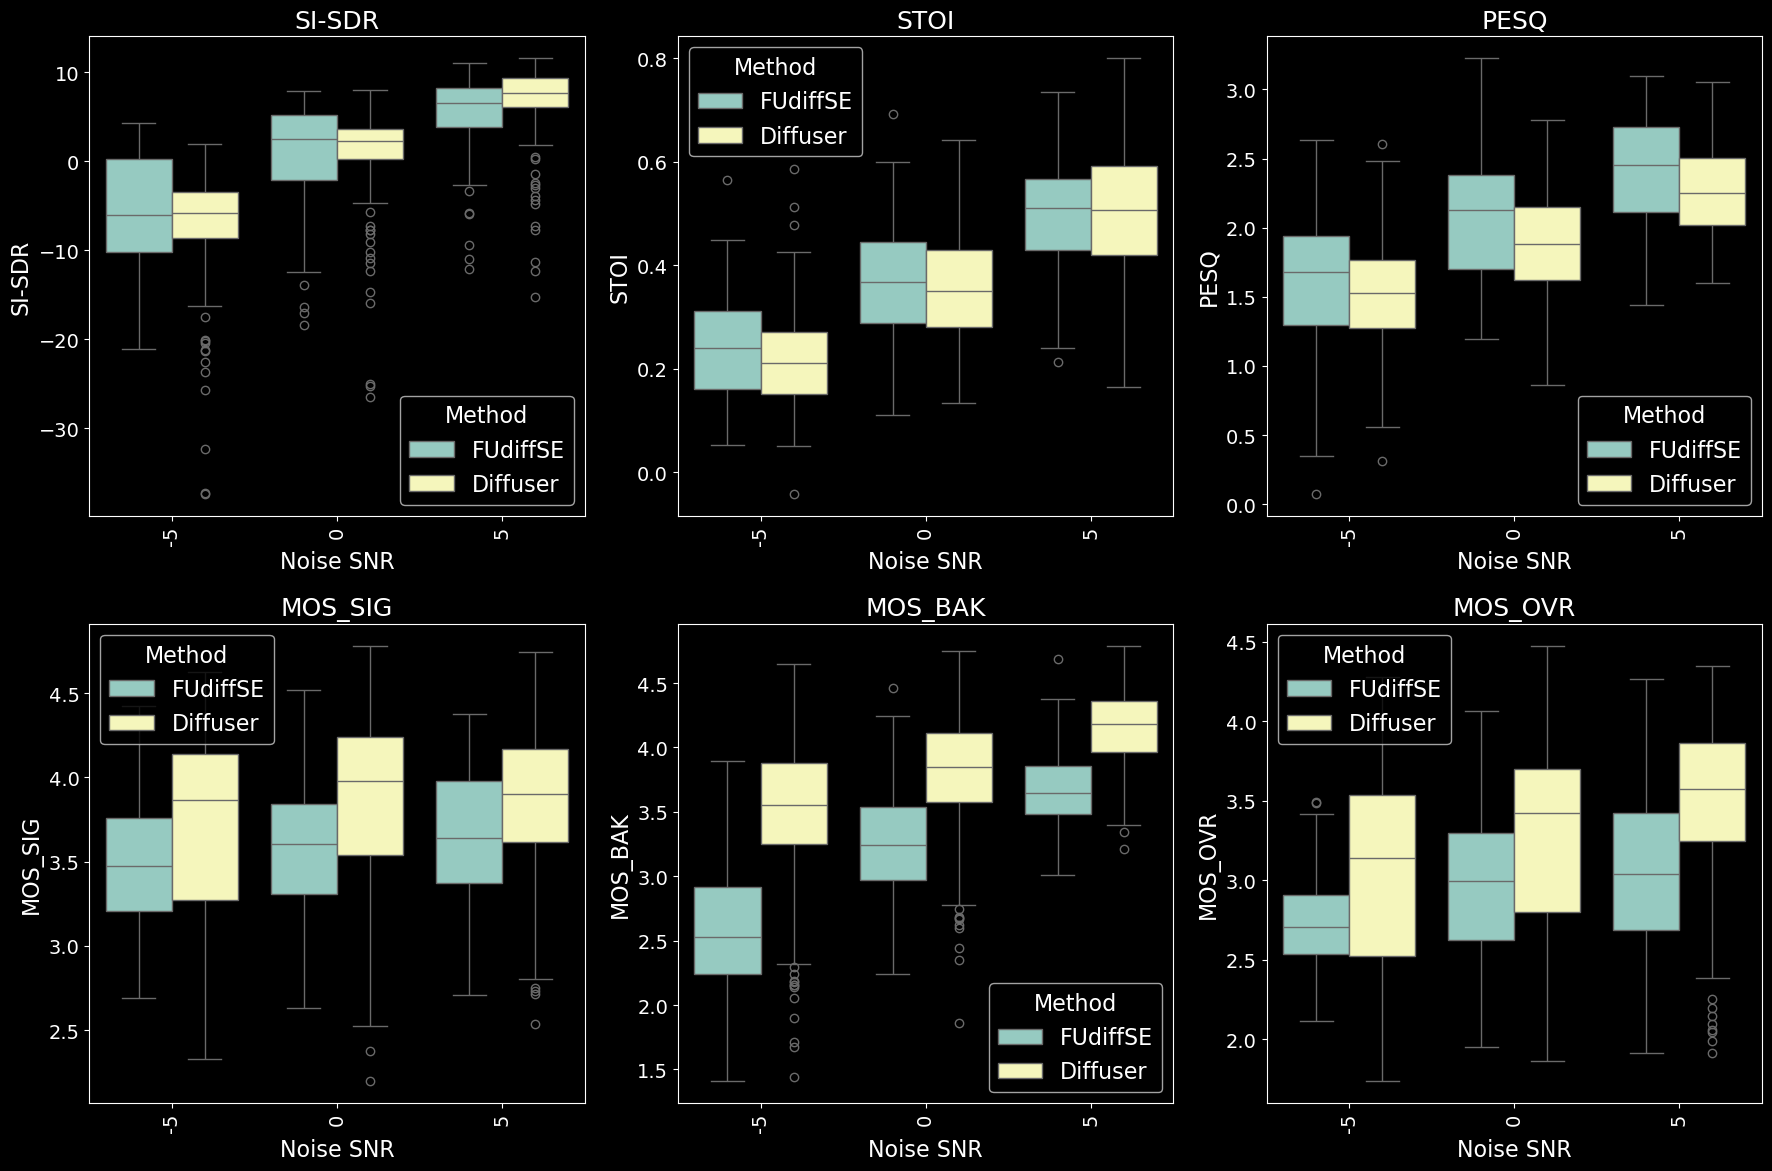

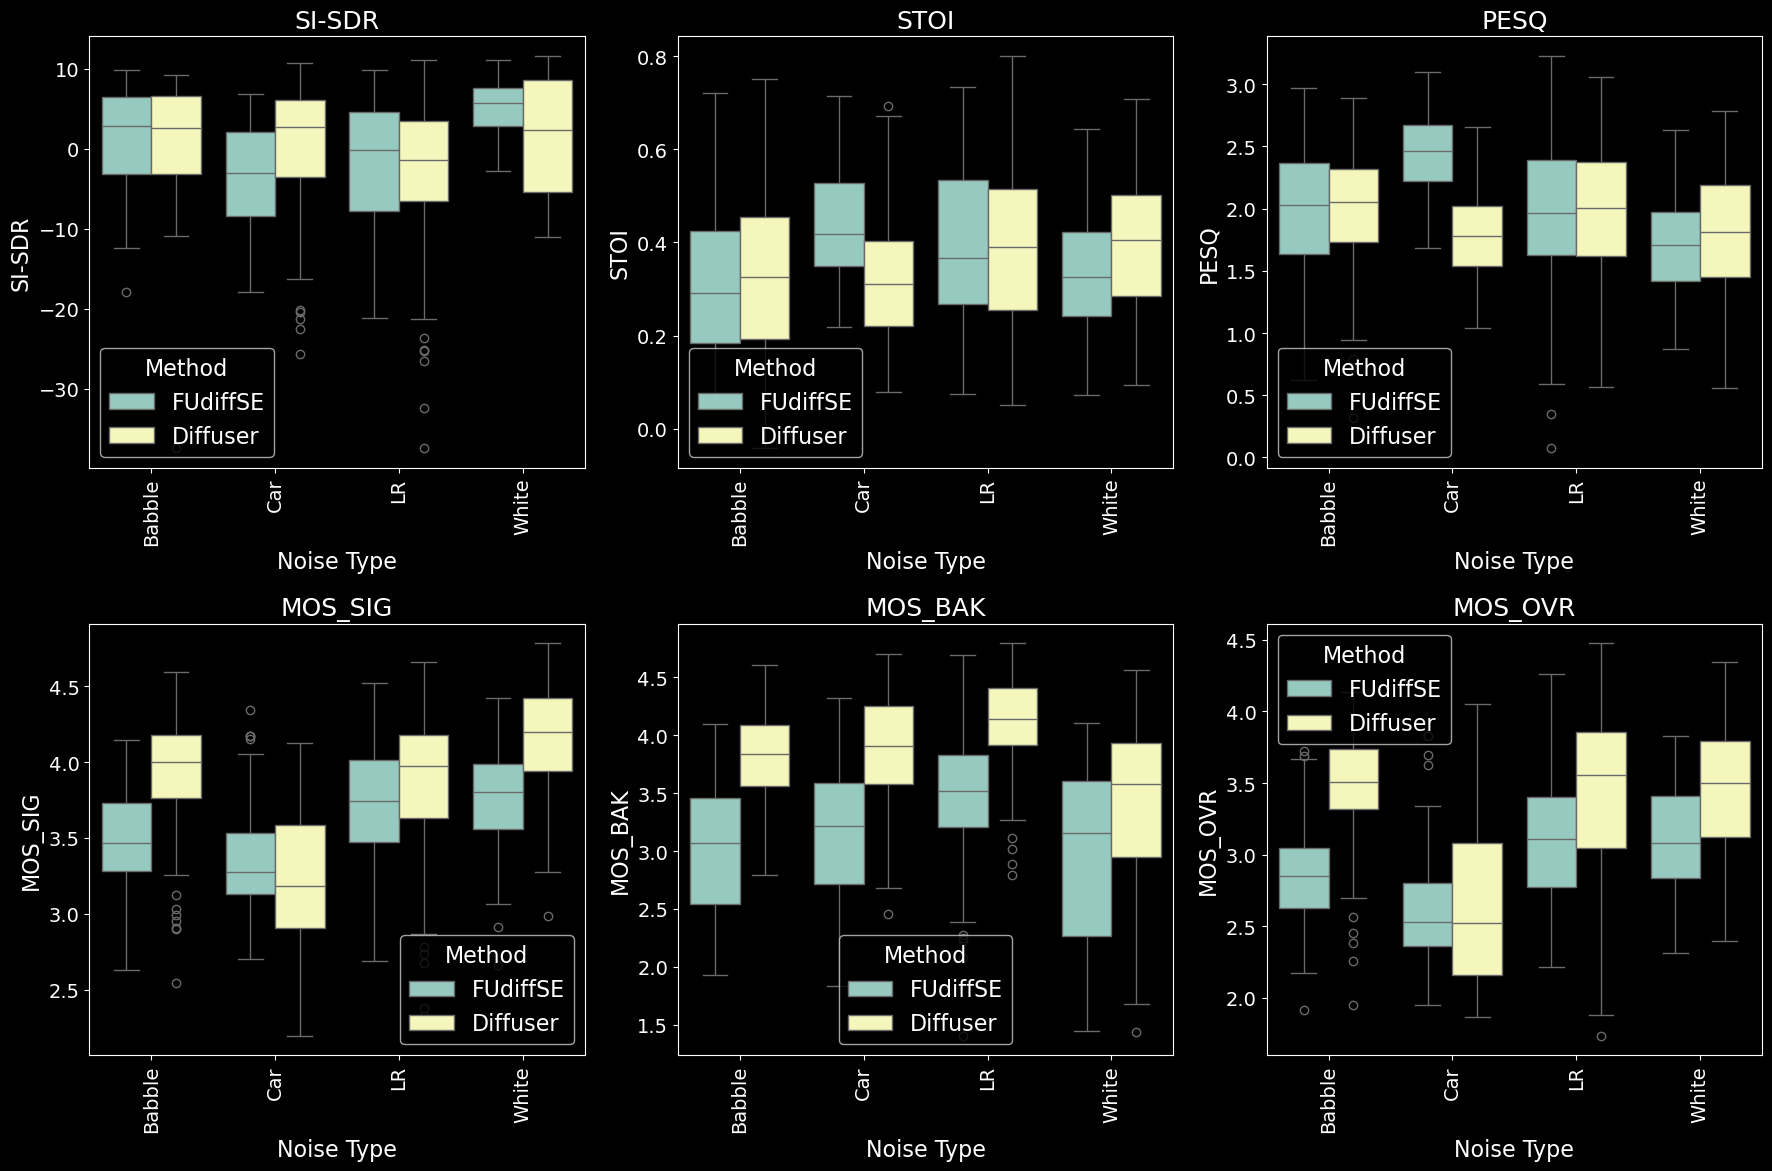

: 

: 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the first new CSV file
file_path_new_1 = '../results/last/TCD-TIMIT/fudiffse/non_linear_orig_12M_reverseEM_bs10/metrics.csv'
df_new_1 = pd.read_csv(file_path_new_1)

# Load the second new CSV file
file_path_new_2 = '../results/last/TCD-TIMIT/fudiffse_v2/non_linear_new_6M_lmbd475/metrics.csv'
df_new_2 = pd.read_csv(file_path_new_2)

# Add a column to distinguish between the two methods
df_new_1['Method'] = 'FUdiffSE'
df_new_2['Method'] = 'Diffuser'

# Combine the two dataframes
combined_new_df = pd.concat([df_new_1, df_new_2], ignore_index=True)

# List of metrics to analyze
metrics = ['SI-SDR', 'STOI', 'PESQ', 'MOS_SIG', 'MOS_BAK', 'MOS_OVR']

# Set font size parameters
plt.rcParams.update({
    'font.size': 16,          # General font size
    'axes.titlesize': 18,     # Title font size
    'axes.labelsize': 16,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,     # Y-tick label font size
})

# Plot each metric as a boxplot to compare different Noise SNRs for both methods
plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Noise SNR', y=metric, hue='Method', data=combined_new_df)
    plt.xticks(rotation=90)
    plt.title(f'{metric}')
plt.tight_layout()
plt.show()

# Plot each metric as a boxplot to compare different Noise Types for both methods
plt.figure(figsize=(18, 12))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Noise Type', y=metric, hue='Method', data=combined_new_df)
    plt.xticks(rotation=90)
    plt.title(f'{metric}')
plt.tight_layout()
plt.show()


/tmp/ipykernel_943941/1150078197.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(methods, fontsize=14)


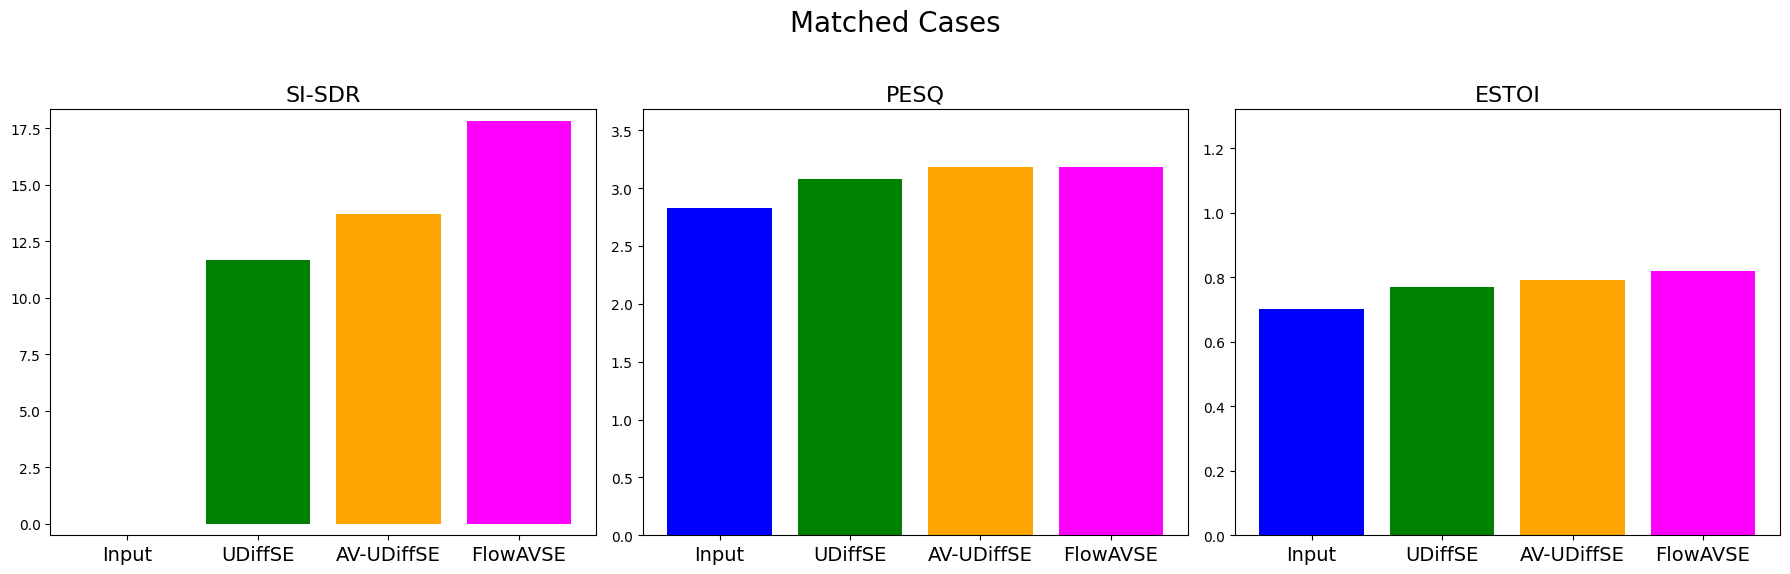

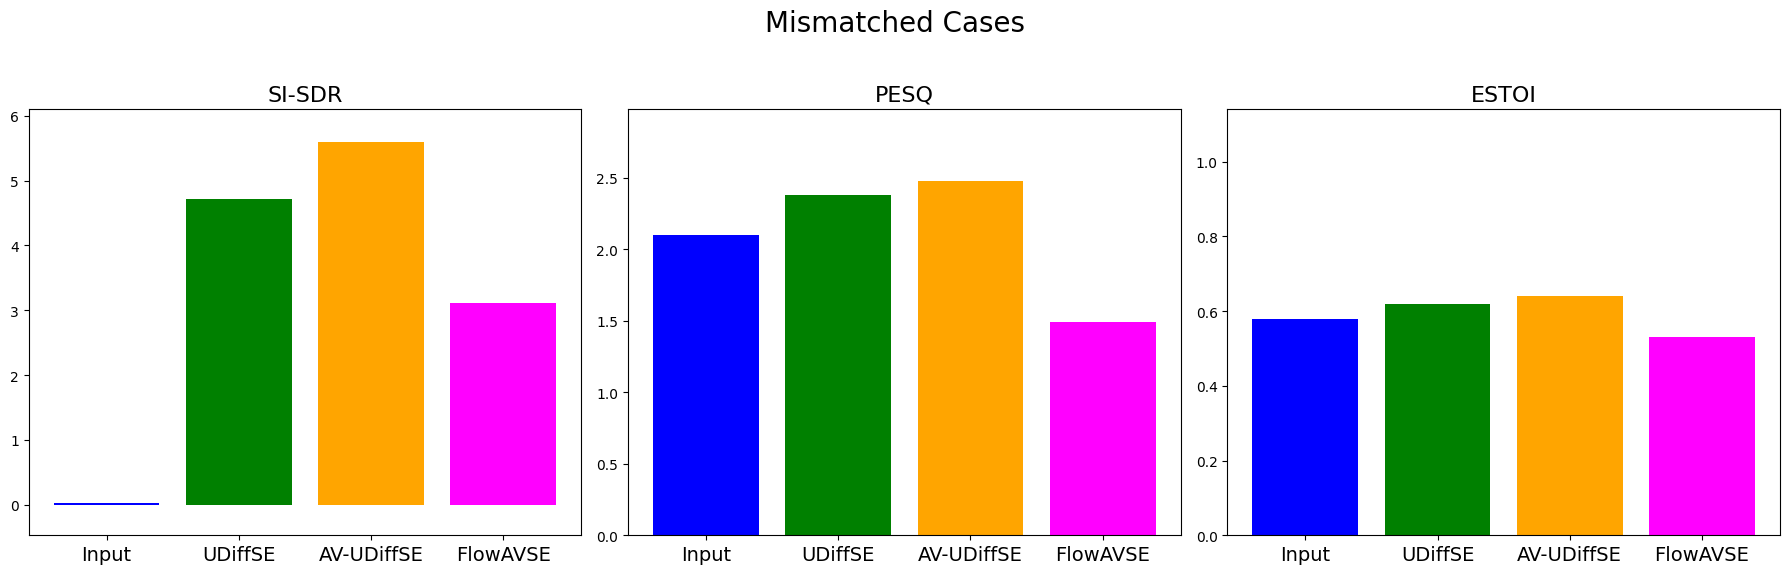

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for matched and mismatched cases including FlowAVSE
methods = ['Input', 'UDiffSE', 'AV-UDiffSE', 'FlowAVSE']
matched_sisdr = [0.00, 11.69, 13.70, 17.83]
matched_pesq = [2.83, 3.08, 3.18, 3.18]
matched_estoi = [0.70, 0.77, 0.79, 0.82]

mismatched_sisdr = [0.03, 4.72, 5.60, 3.12]
mismatched_pesq = [2.10, 2.38, 2.48, 1.49]
mismatched_estoi = [0.58, 0.62, 0.64, 0.53]

def create_figure(data, title, metrics):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(title, fontsize=20)

    for i, ax in enumerate(axs):
        bars = ax.bar(methods, data[i], color=['blue', 'green', 'orange', 'magenta'])
        ax.set_title(metrics[i], fontsize=16)
        ax.set_ylim([min(min(data[i])-0.5, 0), max(data[i])+0.5])
        ax.set_xticklabels(methods, fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Matched case figure
create_figure([matched_sisdr, matched_pesq, matched_estoi], 'Matched Cases', ['SI-SDR', 'PESQ', 'ESTOI'])

# Mismatched case figure
create_figure([mismatched_sisdr, mismatched_pesq, mismatched_estoi], 'Mismatched Cases', ['SI-SDR', 'PESQ', 'ESTOI'])
